# Archived legacy modeling notebook

This is the older combined modeling notebook. It is kept mainly so the earlier feature-building and modeling steps can still be traced.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
cscl = pd.read_csv("CSCL.csv")

In [4]:
resurfacing = pd.read_csv("dot_inhouse_resurfacing.csv")

/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_9169/4173915621.py:1: DtypeWarning: Columns (0,5,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  resurfacing = pd.read_csv("dot_inhouse_resurfacing.csv")


/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_9169/3374029234.py:53: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.xticks(pd.date_range(start_bin, end_bin, freq="M"), rotation=45)


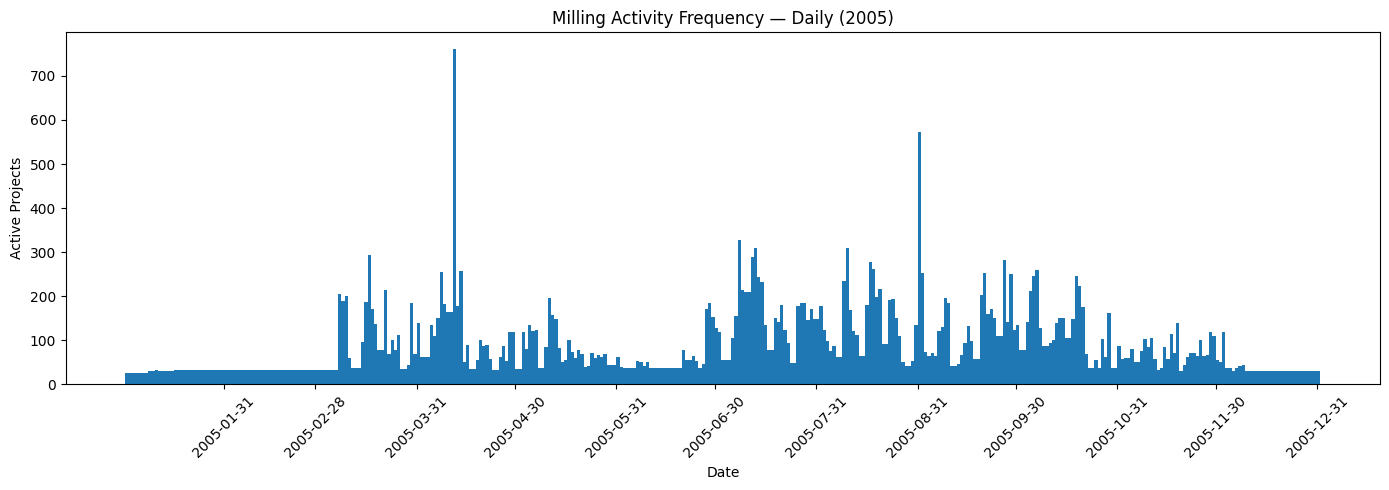

/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_9169/3374029234.py:63: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.xticks(pd.date_range(start_bin, end_bin, freq="M"), rotation=45)


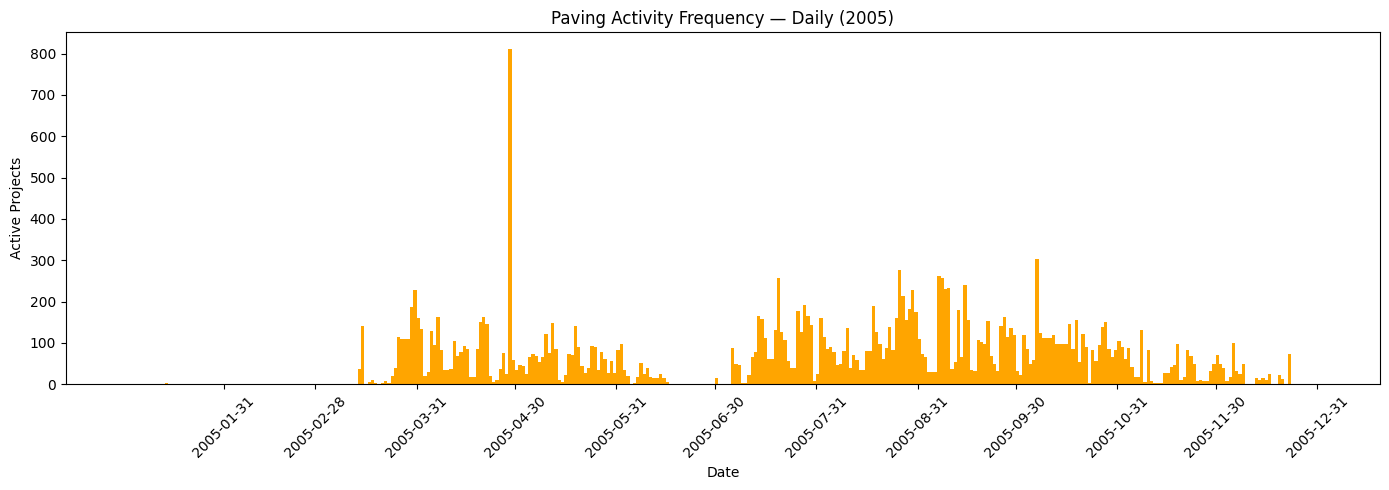

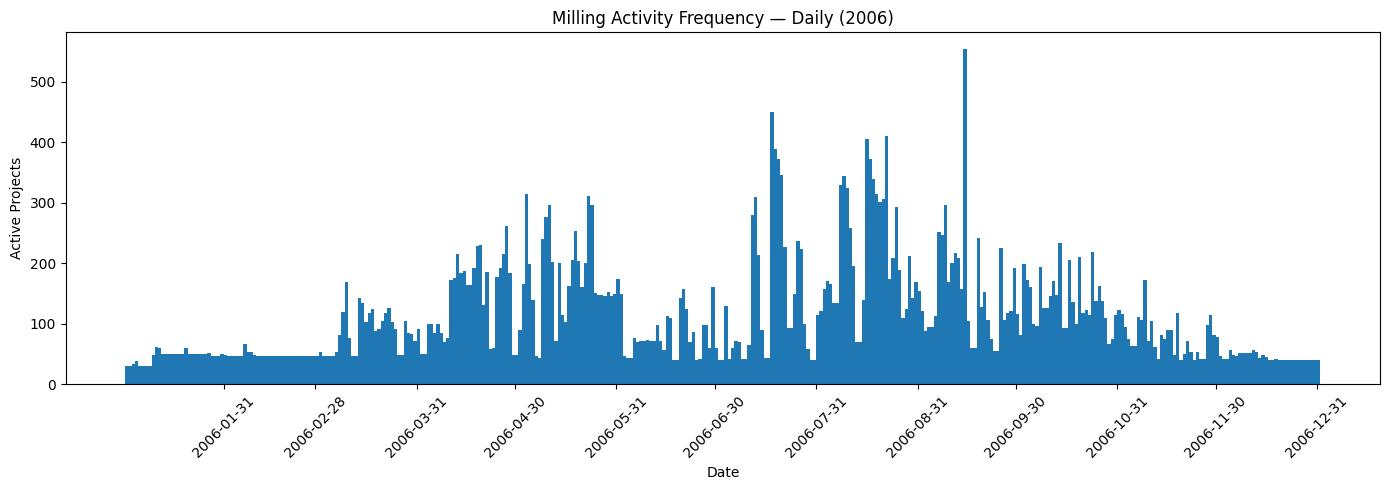

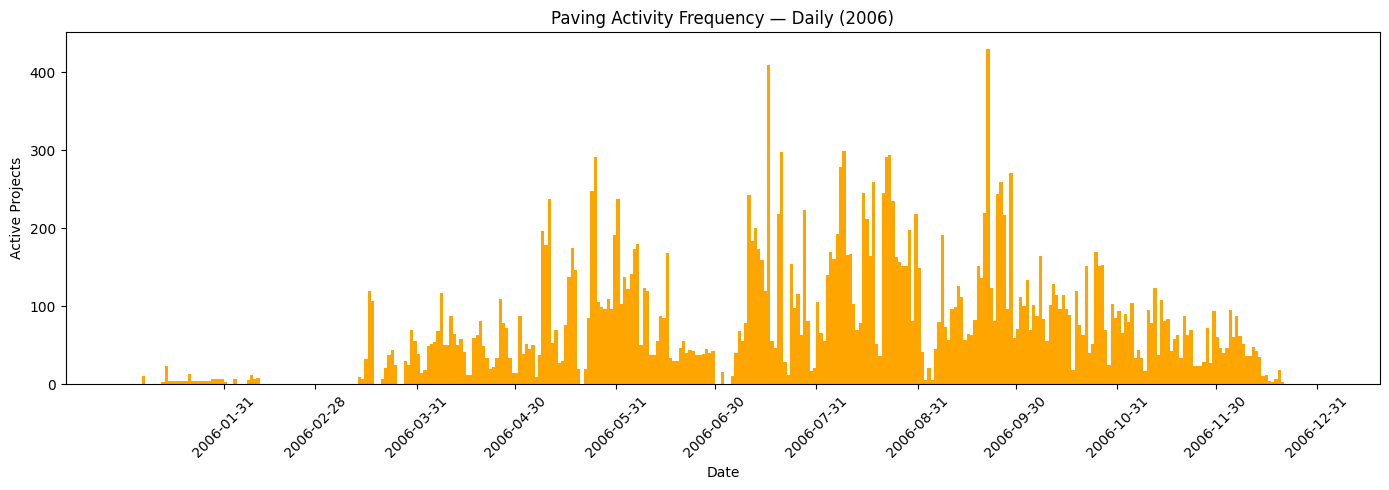

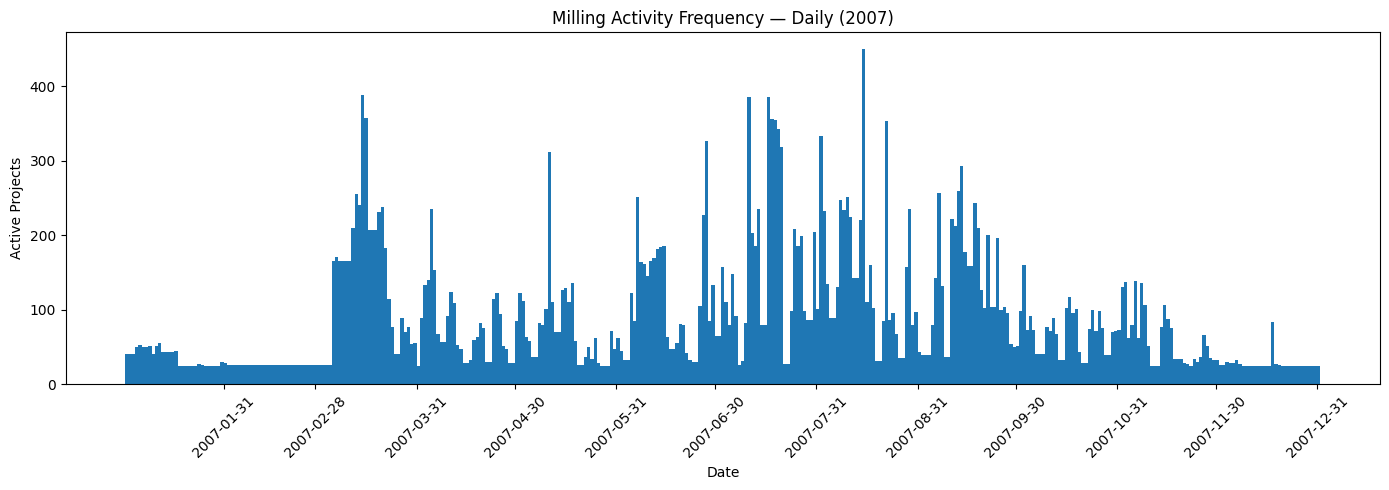

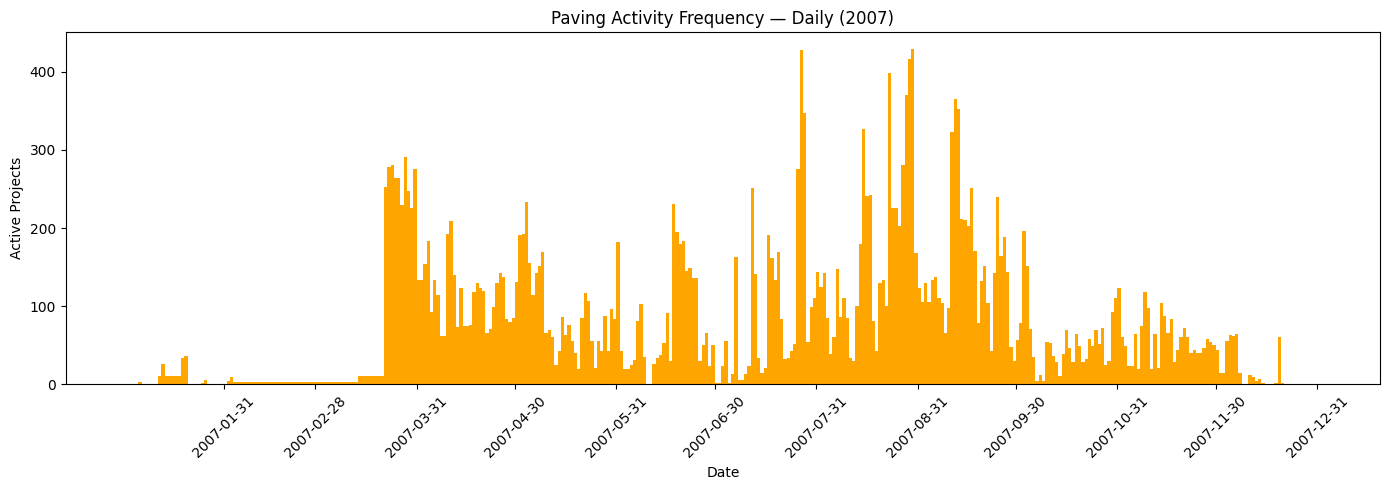

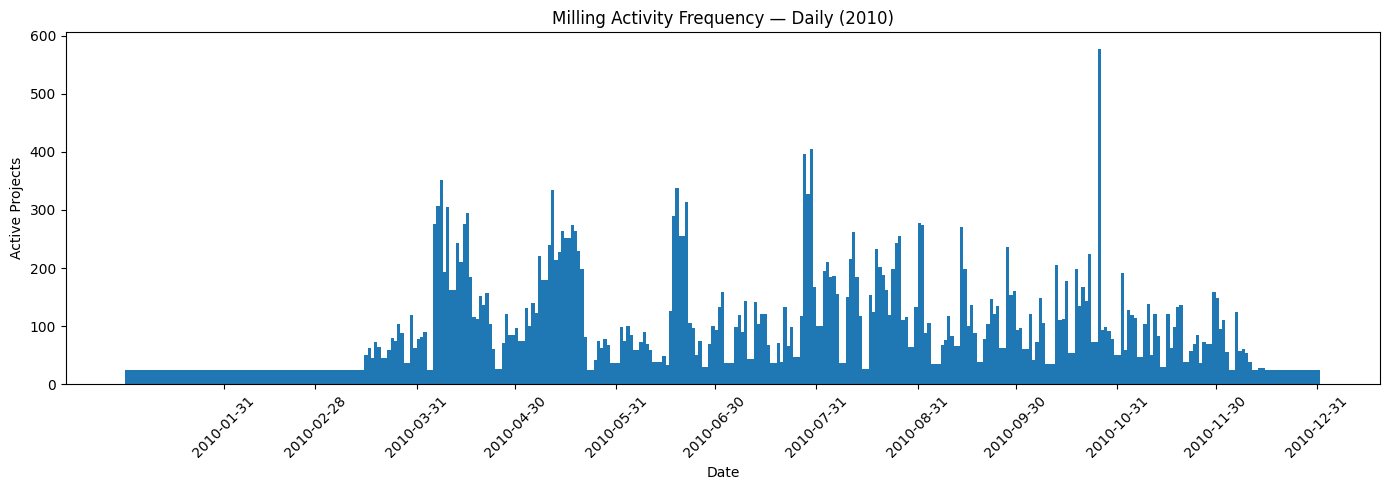

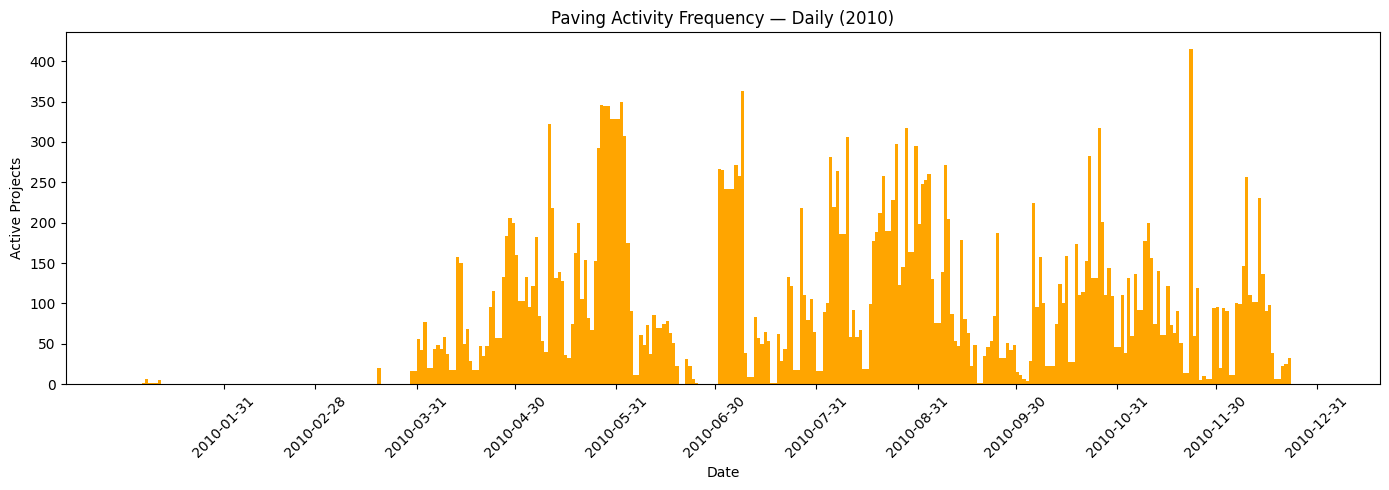

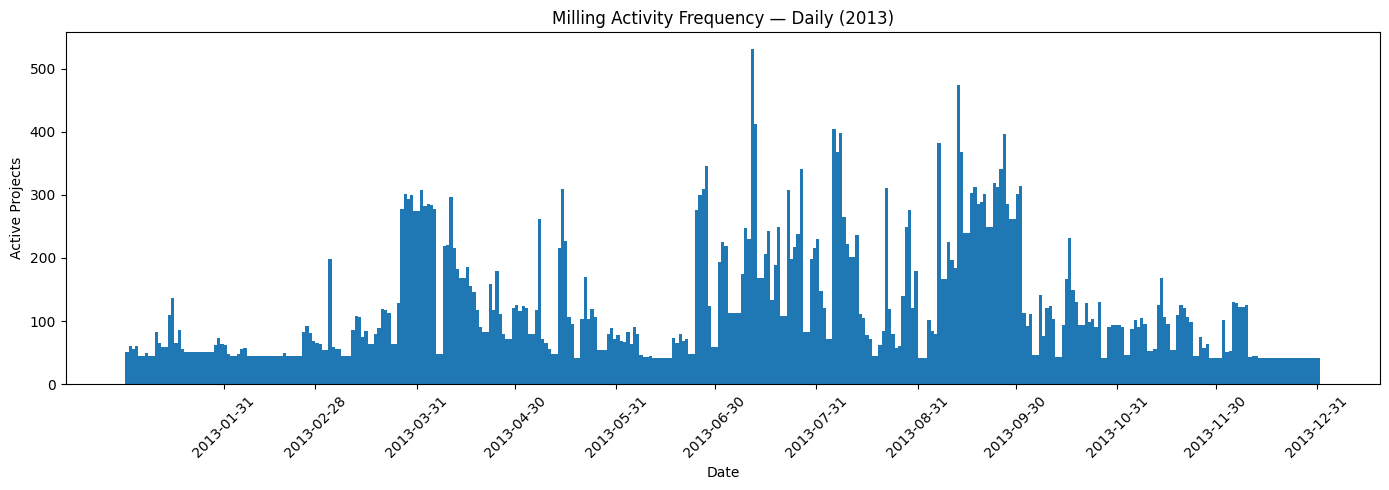

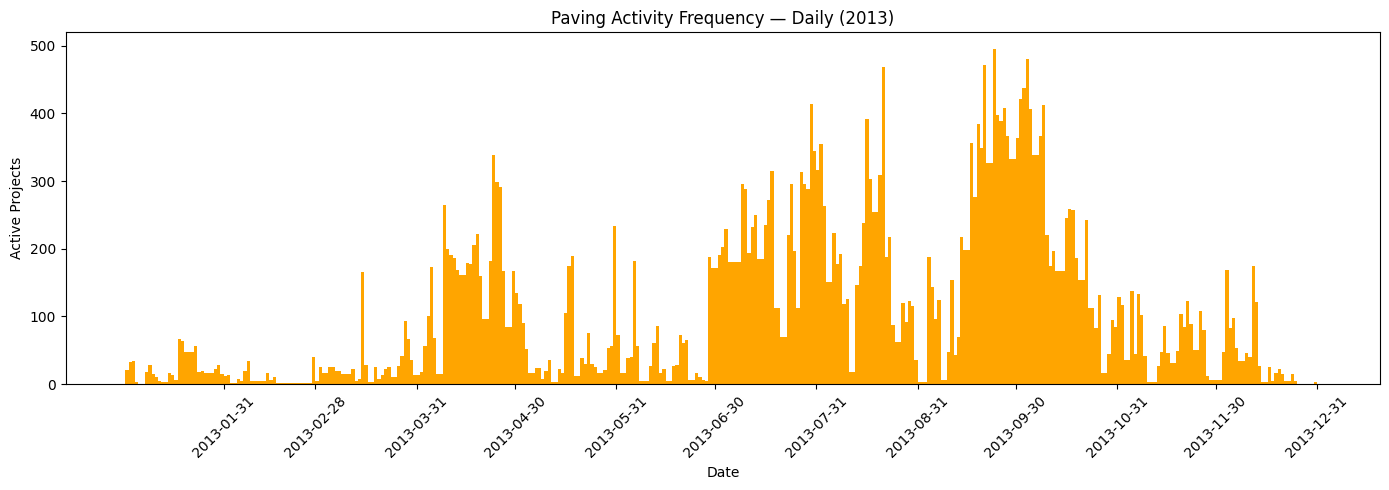

In [ ]:
# Convert date columns to datetime
for col in [
    "Location Actual Milling Start Date",
    "Location Actual Milling End Date",
    "Location Actual Paving Start Date",
    "Location Actual Paving End Date"
]:
    resurfacing[col] = pd.to_datetime(resurfacing[col], errors='coerce', format="%m/%d/%Y")

def make_activity_histogram(start_series, end_series, bins):
    counts = np.zeros(len(bins) - 1, dtype=int)
    for start, end in zip(start_series, end_series):
        if pd.isna(start) or pd.isna(end):
            continue
        s = max(start, bins[0])
        e = min(end, bins[-1])
        if s > e:
            continue
        mask = (bins[:-1] >= s) & (bins[:-1] <= e)
        counts[mask] += 1
    return counts

# Years to process
years = {2005, 2006, 2007, 2010, 2013}  # sample of years to look at milling/paving data temporal distribution

for y in years:
    start_bin = pd.Timestamp(f"{y}-01-01")
    end_bin = pd.Timestamp(f"{y+1}-01-01")  # up to Jan 1 of next year
    bins = pd.date_range(start_bin, end_bin, freq="1D")

    # Compute daily activity
    milling_counts = make_activity_histogram(
        resurfacing["Location Actual Milling Start Date"],
        resurfacing["Location Actual Milling End Date"],
        bins
    )
    paving_counts = make_activity_histogram(
        resurfacing["Location Actual Paving Start Date"],
        resurfacing["Location Actual Paving End Date"],
        bins
    )

    # Milling plot
    plt.figure(figsize=(14, 5))
    plt.bar(bins[:-1], milling_counts, width=1.0, align="edge")
    plt.title(f"Milling Activity Frequency — Daily ({y})")
    plt.xlabel("Date")
    plt.ylabel("Active Projects")
    plt.xticks(pd.date_range(start_bin, end_bin, freq="M"), rotation=45)
    plt.tight_layout()
    plt.show()

    # Paving plot
    plt.figure(figsize=(14, 5))
    plt.bar(bins[:-1], paving_counts, width=1.0, align="edge", color="orange")
    plt.title(f"Paving Activity Frequency — Daily ({y})")
    plt.xlabel("Date")
    plt.ylabel("Active Projects")
    plt.xticks(pd.date_range(start_bin, end_bin, freq="M"), rotation=45)
    plt.tight_layout()
    plt.show()


get nearest weather station for given cscl row

In [270]:
from shapely import wkt
import numpy as np

# Define station coordinates
stations = np.array([
    [40.703, -74.006],  # 1 City Hall
    [40.597, -73.916],  # 2 Brooklyn Salt Marsh
    [40.649, -73.790],  # 3 JFK
    [40.774, -73.879],  # 4 LGA
    [40.849, -73.878],  # 5 Bronx Zoo
    [40.588, -74.140],  # 6 Staten Island
])

def nearest_station(the_geom_wkt):
    # Parse geometry
    geom = wkt.loads(the_geom_wkt)

    # Extract one representative coordinate
    # (e.g., first coordinate of first LineString)
    if geom.geom_type == "MultiLineString":
        coord = geom.geoms[0].coords[0]
    elif geom.geom_type == "LineString":
        coord = geom.coords[0]
    else:
        return None  # skip invalid geometry

    lat, lon = coord[1], coord[0]  # assuming WKT order is (x, y) = (lon, lat)
    
    # Compute Euclidean distance in degrees
    # (sufficient for NYC-scale comparisons)
    dists = np.sqrt((stations[:,0] - lat)**2 + (stations[:,1] - lon)**2)
    
    # Return station index (1-based)
    return int(np.argmin(dists) + 1)

# Apply to DataFrame
cscl['nearest_station'] = cscl['the_geom'].apply(nearest_station)

make normalized_street_name column

In [63]:
from street_normalize import normalize

In [272]:
cscl["normalized_street_name"] = (
    cscl["Borough Code"].astype(str)
    + "-"
    + cscl["Full Street Name"].apply(normalize)
)

IMPUTATION of values: use POST_TYPE from CSCL and take median values for Segment Length and Street Width for whichever is missing (or both). If POST_TYPE is missing and at least one of Segment Length or Street Width is missing, check if that normalized_street_name shows up in the DOT dataset and look at them manually

but also consider PRE_TYPE, only one should be populated, take either. if both populated take that if same, ignore if different

In [7]:
dot_to_cscl = pd.read_csv("dot_to_cscl.csv")

In [273]:
import numpy as np
import pandas as pd

# --- 1. Compute median values grouped by type (either POST_TYPE or PRE_TYPE) ---
# Flatten POST_TYPE and PRE_TYPE into a single "type" for median calculation
cscl_types = cscl.copy()
cscl_types["TYPE"] = cscl_types.apply(
    lambda r: r["POST_TYPE"] if pd.notna(r["POST_TYPE"]) else r["PRE_TYPE"], axis=1
)

medians = (
    cscl_types.groupby("TYPE")[["Segment Length", "Street Width"]]
    .median(numeric_only=True)
)

# --- 2. Function to impute by type ---
def impute_by_type(row):
    # Determine the type to use
    types_present = []
    if pd.notna(row["POST_TYPE"]):
        types_present.append(row["POST_TYPE"])
    if pd.notna(row["PRE_TYPE"]):
        types_present.append(row["PRE_TYPE"])
    
    if len(types_present) == 1:
        t = types_present[0]
    elif len(types_present) == 2:
        if types_present[0] == types_present[1]:
            t = types_present[0]
        else:
            t = None  # conflict, cannot impute
    else:
        t = None  # neither populated
    
    if t and t in medians.index:
        if pd.isna(row["Segment Length"]):
            row["Segment Length"] = medians.loc[t, "Segment Length"]
        if pd.isna(row["Street Width"]):
            row["Street Width"] = medians.loc[t, "Street Width"]
    return row

# Apply imputation
cscl = cscl.apply(impute_by_type, axis=1)

# --- 3. Handle rows where type info missing but Segment Length or Street Width is missing ---
mask_missing_type = (cscl["POST_TYPE"].isna() & cscl["PRE_TYPE"].isna()) & (
    cscl["Segment Length"].isna() | cscl["Street Width"].isna()
)
problem_rows = cscl[mask_missing_type].copy()

# Normalize DOT names
dot_to_cscl["normalized_dot_name"] = dot_to_cscl["DOT street name"].apply(normalize)

# Check which normalized names appear in DOT dataset
problem_rows["in_dot_dataset"] = problem_rows["normalized_street_name"].isin(
    dot_to_cscl["normalized_dot_name"]
)

# Extract for manual review
manual_review = problem_rows[problem_rows["in_dot_dataset"]]
manual_review_not_found = problem_rows[~problem_rows["in_dot_dataset"]]

# Save for manual checking
manual_review.to_csv("imputation_manual_check_found.csv", index=False)
manual_review_not_found.to_csv("imputation_manual_check_not_found.csv", index=False)


In [9]:
manual_review.shape

(0, 67)

No corresponding DOT entries in the segments with imputed values!

In [10]:
cscl[cscl["normalized_street_name"] == "1-1 drive"]   # checking imputation

,the_geom,PHYSICALID,L_LOW_HN,L_HIGH_HN,R_LOW_HN,R_HIGH_HN,L_ZIP,R_ZIP,STATUS,BIKE_LANE,...,Full Street Name,BIKE TRAFFIC DIRECTION,SHAPE__Length,GlobalID,SEGMENT_TYPE,SEGMENT_TYPE_VALUE,STREET NAME,Street Name Label,nearest_station,normalized_street_name
80515,MULTILINESTRING ((-73.924827103755 40.78923281...,136119,NaN,NaN,NaN,NaN,10035.0,10035.0,2,NaN,...,1 DR,NaN,65.796850,a9f1c5df-9404-4e95-adda-052ef6e741cb,NaN,NaN,1,1 DR,4,1-1 drive
90732,MULTILINESTRING ((-73.924549081252 40.78962771...,136142,NaN,NaN,NaN,NaN,10035.0,10035.0,2,NaN,...,1 DR,NaN,232.186532,64f5b839-30c0-4e7c-866c-01753f3dacac,NaN,NaN,1,1 DR,4,1-1 drive
93464,MULTILINESTRING ((-73.923473209416 40.79098057...,136144,NaN,NaN,NaN,NaN,10035.0,10035.0,2,NaN,...,1 DR,NaN,183.939352,19ab0287-0ff4-4591-8510-e44d05b4881b,NaN,NaN,1,1 DR,4,1-1 drive


make a street_type column in cscl for ease of reference

In [274]:
def choose_street_type(row):
    pre, post = row['PRE_TYPE'], row['POST_TYPE']
    if pd.isna(pre) and pd.isna(post):
        return np.nan
    if pd.isna(pre):
        return post
    if pd.isna(post):
        return pre
    if pre == post:
        return pre
    # both populated and different
    return np.random.choice([pre, post])

cscl['street_type'] = cscl.apply(choose_street_type, axis=1)

In [275]:
cscl = cscl[["PHYSICALID", "normalized_street_name", "Segment Length", "Street Width", "nearest_station", "street_type"]]

In [12]:
# dictionary normalized street name: all physical id's with that street name

name_to_ids = (
    cscl.groupby("normalized_street_name")["PHYSICALID"]
    .apply(list)
    .to_dict()
)

In [13]:
len(name_to_ids)

12000

new df called street_snowfall constructed as follows: it has a "normalized_street_name" column, and a "snowfall 20XX" column. the normalized_street_name goes over all those keys from the above dictionary. the snowfall column value is obtained as follows: Segment Length * Street Width * sum(snowfall (cm)) where Segment Length and Street Width are the values in those named columns in the df cscl with that same normalized_street_name, and sum(snowfall(cm)) is the sum of (*) entries in the column "snowfall (cm)" in weather_hourly_i where i is the value in nearest_station in cscl df for that normalized_street_name (might not be unique row, just choose any row with that normalized_street_name), where (*) means cover nov 21 20XX-1 to mar 20 20XX (e.g. nov 21 2015 to mar 20 2016 for 20XX = 2016), and 20XX goes from 2016 to 2025

In [15]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# === PARAMETERS ===
years = range(2016, 2026)
weather_dir = Path(".")  # directory containing weather_hourly_i.csv

# === LOAD WEATHER FILES AND COMPUTE TOTAL SNOWFALL BY YEAR ===
station_snow = {}

for i in range(1, 7):
    f = weather_dir / f"weather_hourly_{i}.csv"
    df = pd.read_csv(f, skiprows = 3)

    # Ensure valid datetime and numeric columns
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df['snowfall (cm)'] = pd.to_numeric(df['snowfall (cm)'], errors='coerce')

    totals = {}
    for y in years:
        start = pd.Timestamp(y - 1, 11, 21)
        end = pd.Timestamp(y, 3, 20, 23, 59, 59)
        mask = (df['time'] >= start) & (df['time'] <= end)
        totals[y] = df.loc[mask, 'snowfall (cm)'].sum(skipna=True)
    station_snow[i] = totals

# === AGGREGATE PER STREET ===
records = []

for name, group in cscl.groupby("normalized_street_name"):
    # Take any representative nearest_station value
    station = int(group['nearest_station'].iloc[0])
    # Sum over all segments for this normalized street
    area_factor = (group['Segment Length'] * group['Street Width']).sum()

    row = {'normalized_street_name': name, 'total_area': area_factor / 9} # convert to square yards
    for y in years:
        row[f'snowfall {y}'] = area_factor * station_snow[station][y] / 9  # convert to square yards
    records.append(row)

street_snowfall = pd.DataFrame(records)

# === OPTIONAL SORTING ===
#street_snowfall = street_snowfall.sort_values("normalized_street_name").reset_index(drop=True)



snowfall 20XX means November 21 20XX-1 to March 20 20XX inclusive

In [16]:
street_snowfall.head()

,normalized_street_name,total_area,snowfall 2016,snowfall 2017,snowfall 2018,snowfall 2019,snowfall 2020,snowfall 2021,snowfall 2022,snowfall 2023,snowfall 2024,snowfall 2025
0,1-1 avenue,253446.943078,1.332371e+07,1.846868e+07,2.038474e+07,1.218826e+07,7.131997e+06,2.198145e+07,1.245438e+07,6.369122e+06,8.994832e+06,9.243210e+06
1,1-1 avenue loop,3156.346367,1.659291e+05,2.178510e+05,2.543068e+05,1.462651e+05,8.638920e+04,2.675635e+05,1.506840e+05,8.042371e+04,1.206356e+05,1.056113e+05
2,1-1 drive,1524.830711,8.016035e+04,1.111144e+05,1.226421e+05,7.332911e+04,4.290874e+04,1.322486e+05,7.493018e+04,3.831900e+04,5.411624e+04,5.561058e+04
3,1-1 place,1922.967599,1.010904e+05,1.327232e+05,1.549335e+05,8.911032e+04,5.263162e+04,1.630100e+05,9.180247e+04,4.899721e+04,7.349582e+04,6.434250e+04
4,1-10 avenue,118024.842056,6.204566e+06,8.146075e+06,9.509262e+06,5.469271e+06,3.230340e+06,1.000497e+07,5.634506e+06,3.007273e+06,4.510909e+06,3.949111e+06


new df called street_weather constructed as follows: it has a "normalized_street_name" column, and columns "DATA 20XX" where DATA is in {temperature, apparent_temperature, snowfall, snow_depth, precipitation, relative_humidity, cloud_cover, wind_gusts_10m, wind_speed_10m}. normalized_street_name goes over all those keys from the dictionary name_to_ids. all other values are computed as the average value across (*) entries in the column whose name begins with that given string (e.g. temperature will be the start of actual string name "temperate_2m (degrees F)" in the corresponding csv) in weather_hourly_i where i is the value in nearest_station in cscl df for that normalized_street_name (might not be unique row, just choose any row with that normalized_street_name), where (*) means cover november 21 20XX-1 to march 20 20XX (e.g. november 21 2015 to march 20 2016 for 20XX = 2016), and 20XX goes from 2016 to 2025

In [196]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Config ---
weather_dir = Path(".")  # set to your actual path
YEARS = range(2016, 2026)
VARIABLES = [
    "temperature",
    "apparent_temperature",
    "snowfall",
    "snow_depth",
    "precipitation",
    "relative_humidity",
    "cloud_cover",
    "wind_gusts_10m",
    "wind_speed_10m",
]

# --- Load weather_hourly_i CSVs ---
weather_hourly = {}
for i in range(1, 7):
    f = weather_dir / f"weather_hourly_{i}.csv"
    df = pd.read_csv(f, skiprows=3)
    # Try to find datetime column heuristically
    datetime_col = next(c for c in df.columns if "time" in c.lower())
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    df.rename(columns={datetime_col: "datetime"}, inplace=True)
    weather_hourly[i] = df

# --- Helper to match a variable prefix ---
def get_column(df, prefix):
    prefix = prefix.lower()
    for c in df.columns:
        if c.lower().startswith(prefix):
            return c
    raise KeyError(f"No column starts with '{prefix}' in {df.columns[:8]}...")

# --- Map streets to nearest station ---
station_map = cscl.groupby("normalized_street_name")["nearest_station"].first().to_dict()

records = []

for street, ids in name_to_ids.items():
    if street not in station_map:
        continue

    station_id = station_map[street]
    if station_id not in weather_hourly:
        continue

    wdf = weather_hourly[station_id]

    for year in YEARS:
        start = pd.Timestamp(year - 1, 11, 21)
        end = pd.Timestamp(year, 3, 20, 23, 59)
        sub = wdf.loc[(wdf["datetime"] >= start) & (wdf["datetime"] <= end)]

        if sub.empty:
            continue

        entry = {"normalized_street_name": street}
        for var in VARIABLES:
            col = get_column(wdf, var)
            entry[f"{var} {year}"] = sub[col].mean(skipna=True)
        records.append(entry)

# --- Construct final DataFrame ---
street_weather = pd.DataFrame(records)
street_weather = street_weather.groupby("normalized_street_name").first().reset_index()


In [197]:
street_weather.head()

,normalized_street_name,temperature 2016,apparent_temperature 2016,snowfall 2016,snow_depth 2016,precipitation 2016,relative_humidity 2016,cloud_cover 2016,wind_gusts_10m 2016,wind_speed_10m 2016,...,wind_speed_10m 2024,temperature 2025,apparent_temperature 2025,snowfall 2025,snow_depth 2025,precipitation 2025,relative_humidity 2025,cloud_cover 2025,wind_gusts_10m 2025,wind_speed_10m 2025
0,1-1 avenue,39.19511,32.505820,0.018103,0.029601,0.107369,71.353650,61.958333,15.476033,7.501481,...,8.325138,35.128333,27.790000,0.012663,0.015431,0.128403,66.646528,57.226042,16.792431,6.972014
1,1-1 avenue loop,39.55730,32.877307,0.018103,0.030272,0.107369,70.392218,61.958333,15.476033,7.501481,...,8.319318,35.017778,27.823993,0.011618,0.013257,0.131562,67.605556,57.229514,16.065660,6.664340
2,1-1 drive,39.19511,32.505820,0.018103,0.029601,0.107369,71.353650,61.958333,15.476033,7.501481,...,8.325138,35.128333,27.790000,0.012663,0.015431,0.128403,66.646528,57.226042,16.792431,6.972014
3,1-1 place,39.55730,32.877307,0.018103,0.030272,0.107369,70.392218,61.958333,15.476033,7.501481,...,8.319318,35.017778,27.823993,0.011618,0.013257,0.131562,67.605556,57.229514,16.065660,6.664340
4,1-10 avenue,39.55730,32.877307,0.018103,0.030272,0.107369,70.392218,61.958333,15.476033,7.501481,...,8.319318,35.017778,27.823993,0.011618,0.013257,0.131562,67.605556,57.229514,16.065660,6.664340


NOW PROCESS DOT_INHOUSE_RESURFACING (AGAIN)

In [17]:
df = pd.read_csv("dot_inhouse_resurfacing.csv")

/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/1190757471.py:1: DtypeWarning: Columns (0,5,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dot_inhouse_resurfacing.csv")


In [18]:
# Column names
milling_start = "Location Actual Milling Start Date"
milling_end   = "Location Actual Milling End Date"
paving_start  = "Location Actual Paving Start Date"
paving_end    = "Location Actual Paving End Date"

# Create boolean masks for non-missing pairs
milling_mask = df[milling_start].notna() & df[milling_end].notna()
paving_mask  = df[paving_start].notna() & df[paving_end].notna()

# Keep rows where either condition is True
resurfacing = df[milling_mask | paving_mask].copy()

In [ ]:
# drop unnecessary columns

#resurfacing.drop(columns = ['Project ID', 'Location Community Board', 'OFT Code', 'Project Speed Bumps'], inplace = True)



In [20]:
# remove time portion by normalizing
resurfacing[milling_start] = pd.to_datetime(resurfacing[milling_start]).dt.normalize()
resurfacing[milling_end]   = pd.to_datetime(resurfacing[milling_end]).dt.normalize()
resurfacing[paving_start]  = pd.to_datetime(resurfacing[paving_start]).dt.normalize()
resurfacing[paving_end]    = pd.to_datetime(resurfacing[paving_end]).dt.normalize()

# compute durations (end - start + 1 day)
resurfacing["milling_time"] = (abs(resurfacing[milling_end] - resurfacing[milling_start])).dt.days.add(1)
resurfacing["paving_time"]  = (abs(resurfacing[paving_end]  - resurfacing[paving_start])).dt.days.add(1)

# total_time treating NaN as 0
resurfacing["total_time"] = (
    resurfacing["milling_time"].fillna(0) +
    resurfacing["paving_time"].fillna(0)
)

# special case: both durations 1 and exact same day
same_day_overlap = (
    (resurfacing["milling_time"] == 1) &
    (resurfacing["paving_time"] == 1) &
    (resurfacing[milling_start] == resurfacing[paving_start]) &
    (resurfacing[milling_end]   == resurfacing[paving_end])
)
resurfacing.loc[same_day_overlap, "total_time"] = 1

In [ ]:
# extract year from dates
years_valid = (
    (resurfacing[milling_start].dt.year > 2015) &
    (resurfacing[milling_end].dt.year   > 2015) &
    (resurfacing[paving_start].dt.year  > 2015) &
    (resurfacing[paving_end].dt.year    > 2015)
)

# keep only rows where all four dates are after 2015
resurfacing = resurfacing[years_valid].copy()

In [22]:
resurfacing[resurfacing["Location Actual Paving Square Yard"].isna()]

,OFT Code,Project Type,Borough Code,Location On Street,Location From Street,Location To Street,Project ID,Project Status,Location Community Board,Location Actual Milling Start Date,...,Location Actual Protect Until,Location Actual Lane Miles Paved,Location Actual Paving Square Yard,Location Status,Location Segment ID,Location WKT,Location Node ID,milling_time,paving_time,total_time
172116,135370144990000000,Intersection,M,WEST 80 STREET,WEST END AVENUE,NaN,M2020-07-07,Paving Completed,107.0,2020-08-06,...,08/21/2025,NaN,NaN,Paving Completed,21751.0,POINT (989604.13629999757 225283.98800000548),NaN,1.0,1.0,2.0
218902,366130311485354000,Block,B,NORTH 5 STREET,NORTH 4 PLACE,KENT AVENUE,K2021-01-07,Paving Completed,301.0,2021-07-12,...,08/05/2026,NaN,NaN,Paving Completed,34887.0,LINESTRING (994315.15279999375 201485.78319999...,NaN,2.0,1.0,3.0
219327,364830372730380430,Block,B,NEW YORK AVENUE,PROSPECT PLACE,ST MARKS AVENUE,K2019-08-02,Paving Completed,308.0,2021-04-01,...,05/03/2026,NaN,NaN,Paving Completed,29764.0,LINESTRING (998887.72300000489 185220.72280000...,NaN,2.0,1.0,3.0
219478,313430323340397120,Block,B,ATLANTIC AVENUE,BROOKLYN QNS EXPRESSWAY,BK QN EXPRESSWAY ENTRANCE NB,K2019-02-23,Completed Project,NaN,2019-07-15,...,07/31/2024,NaN,NaN,NaN,162455.0,LINESTRING (984471.40379999578 191234.70999999...,NaN,1.0,1.0,2.0
219510,340830363030000000,Intersection,B,FLATBUSH AVENUE EXTENSION,MYRTLE AVENUE,NaN,K2019-02-28,Paving Completed,302.0,2020-11-09,...,11/19/2025,NaN,NaN,Paving Completed,90216.0,MULTIPOINT ((988865.98129999638 192017.4020999...,NaN,8.0,3.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591438,371030318950318950,Block,B,PLAZA STREET,BEND,BEND,K2021-06-15,Paving Completed,NaN,2021-09-16,...,09/24/2026,NaN,NaN,NaN,29154.0,MULTILINESTRING ((992656.60699999332 185330.03...,NaN,1.0,1.0,2.0
591565,318950377030000000,Intersection,B,BEND,BELT PARKWAY,NaN,K2017-13-19,Paving Completed,313.0,2018-09-06,...,09/19/2023,NaN,NaN,Paving Completed,25343.0,MULTIPOINT ((979219.29860000312 159275.9233999...,NaN,1.0,1.0,2.0
591602,336530314380341030,Block,B,EAST 38 STREET,AVENUE P,FLATLANDS AVENUE,K2019-18-15,Paving Completed,318.0,2019-11-07,...,11/21/2024,NaN,NaN,Paving Completed,127964.0,LINESTRING (1001184.0567999929 164752.31290000...,NaN,2.0,1.0,3.0
591697,335530314030314080,Block,B,EAST 16 STREET,AVENUE I,AVENUE J,K2020-14-14,Paving Completed,314.0,2021-08-03,...,08/23/2026,NaN,NaN,Paving Completed,27184.0,LINESTRING (995098.5082000047 167957.549199998...,NaN,1.0,4.0,5.0


IMPUTATION: for a given row with Location Actual Paving Square Yard not populated, impute the value as median across all rows that have that value and that have the same "Project Type" value

In [23]:
from sklearn.impute import SimpleImputer
import pandas as pd

def impute_paving_square_yard(df):
    df = df.copy()
    imputed_groups = []

    for project_type, group in df.groupby("Project Type", dropna=False):
        if pd.notna(project_type):
            imp = SimpleImputer(strategy="median")
            col = "Location Actual Paving Square Yard"

            # Impute only that one column
            group[[col]] = pd.DataFrame(
                imp.fit_transform(group[[col]]),
                index=group.index,
                columns=[col]
            )
        imputed_groups.append(group)

    return pd.concat(imputed_groups, ignore_index=True)

resurfacing = impute_paving_square_yard(resurfacing)


In [24]:
resurfacing["sqyd-days"] = resurfacing["Location Actual Paving Square Yard"]*resurfacing["total_time"]

In [ ]:
resurfacing[resurfacing["sqyd-days"].isna()]  # empty

In [26]:
resurfacing.head()

,OFT Code,Project Type,Borough Code,Location On Street,Location From Street,Location To Street,Project ID,Project Status,Location Community Board,Location Actual Milling Start Date,...,Location Actual Lane Miles Paved,Location Actual Paving Square Yard,Location Status,Location Segment ID,Location WKT,Location Node ID,milling_time,paving_time,total_time,sqyd-days
0,132685116510130790,Block,M,VARICK STREET,DOMINICK STREET,SPRING STREET,M202402002,Paving Completed,102.0,2025-03-17,...,0.22,1380.0,Paving Completed,31905.0,LINESTRING (982616.10899999738 203423.08740000...,NaN,1.0,1.0,2.0,2760.0
1,423590417140417540,Block,Q,155 AVENUE,84 STREET,86 STREET,Q202410031,Paving Completed,410.0,2025-08-14,...,0.19,2080.0,Paving Completed,51390.0,LINESTRING (1025886.7856000066 181453.70960000...,NaN,1.0,1.0,2.0,4160.0
2,542785518510541165,Block,S,PARK LANE,BEND,OAKLAND TERRACE,S202401095,Completed Project,501.0,2025-07-15,...,0.20,1410.0,Paving Completed,112458.0,LINESTRING (959815.02609999478 165270.56640000...,NaN,1.0,1.0,2.0,2820.0
3,420590415390415690,Block,Q,112 STREET,73 AVENUE,75 AVENUE,Q202206053,Paving Completed,406.0,2025-06-23,...,0.15,770.0,Paving Completed,82858.0,LINESTRING (1029261.7590000033 201507.70419999...,NaN,1.0,1.0,2.0,1540.0
4,225860215920242420,Block,X,EAST 140 STREET,BRUCKNER BOULEVARD,JACKSON AVENUE,X202501002,Paving Completed,201.0,2025-06-24,...,0.18,1287.0,Paving Completed,70339.0,LINESTRING (1008596.3481999934 233019.73340000...,NaN,1.0,1.0,2.0,2574.0


In [27]:
import pandas as pd
import numpy as np

# Columns of interest
cols = [
    "Borough Code",
    "Location On Street",
    "Location Actual Milling Start Date",
    "Location Actual Milling End Date",
    "Location Actual Paving Start Date",
    "Location Actual Paving End Date",
    "Location Actual Paving Square Yard",
    "sqyd-days",
]

resurfacing_temp = resurfacing[cols].copy()

# Convert all date columns to datetime (safe coercion)
date_cols = [
    "Location Actual Milling Start Date",
    "Location Actual Milling End Date",
    "Location Actual Paving Start Date",
    "Location Actual Paving End Date",
]
for c in date_cols:
    resurfacing_temp[c] = pd.to_datetime(resurfacing_temp[c], errors="coerce")

# Compute start_date and end_date as min/max across the four date fields (per row)
resurfacing_temp["start_date"] = resurfacing_temp[date_cols].min(axis=1)
resurfacing_temp["end_date"] = resurfacing_temp[date_cols].max(axis=1)

# Keep only desired columns
resurfacing_temp = resurfacing_temp[
    ["Borough Code", "Location On Street", "start_date", "end_date", "Location Actual Paving Square Yard", "sqyd-days"]
]


In [28]:
resurfacing_temp.head()

,Borough Code,Location On Street,start_date,end_date,Location Actual Paving Square Yard,sqyd-days
0,M,VARICK STREET,2025-03-17,2025-03-25,1380.0,2760.0
1,Q,155 AVENUE,2025-08-14,2025-08-25,2080.0,4160.0
2,S,PARK LANE,2025-07-15,2025-07-23,1410.0,2820.0
3,Q,112 STREET,2025-06-23,2025-07-17,770.0,1540.0
4,X,EAST 140 STREET,2025-06-24,2025-07-07,1287.0,2574.0


In [29]:
#borough code map from DOT to CSCL

borough_map = {'M': '1', 'X': '2', 'B': '3', 'Q': '4', 'S': '5'}  # Manhattan, Bronx, Queens, Brooklyn, Staten Island


In [30]:
# Map Borough Code letters to numbers
resurfacing_temp["Borough Number"] = resurfacing_temp["Borough Code"].map(borough_map)

# Apply normalization to street
resurfacing_temp["normalized_street_name"] = (
    resurfacing_temp["Borough Number"].astype(str) + "-" +
    resurfacing_temp["Location On Street"].apply(normalize)
)

# Drop original columns
resurfacing_temp = resurfacing_temp.drop(columns=["Borough Code", "Location On Street", "Borough Number"])

# Rename and reorder columns

resurfacing_temp = resurfacing_temp.rename(columns = {"Location Actual Paving Square Yard": "area"})
resurfacing_temp = resurfacing_temp[
    ["normalized_street_name", "start_date", "end_date", "area", "sqyd-days"]
]


now aggregate by street, and restrict to PAVING season March 21 - Nov 20 (include days in that range even if full range contains more, truncate); one row for each street

In [31]:
import pandas as pd

# Define roadwork season boundaries (month/day only)
ROADWORK_START = (3, 21)
ROADWORK_END = (11, 20)

def overlaps_roadwork_season(start, end):
    """Return list of years whose roadwork season [Mar 21, Nov 20] overlaps the given interval."""
    if pd.isna(start) or pd.isna(end):
        return []
    if start > end:
        start, end = end, start

    years = []
    for y in range(start.year, end.year + 1):
        s = pd.Timestamp(y, 3, 21)
        e = pd.Timestamp(y, 11, 20, 23, 59, 59)
        if start <= e and end >= s:
            years.append(y)
    return years

records = []
for _, row in resurfacing_temp.iterrows():
    years = overlaps_roadwork_season(row["start_date"], row["end_date"])
    for y in years:
        records.append({
            "normalized_street_name": row["normalized_street_name"],
            "roadwork_season": y,
            "sqyd-days": row["sqyd-days"],
            "area": row["area"]
        })

resurfacing_agg = (
    pd.DataFrame(records)
    .groupby(["normalized_street_name", "roadwork_season"], as_index=False)[["sqyd-days", "area"]]
    .sum()
    .round({"sqyd-days": 1, "area": 1})
    .sort_values(["normalized_street_name", "roadwork_season"], ascending=[True, True])
    .reset_index(drop=True)
)


In [32]:
resurfacing_agg.head(20)

,normalized_street_name,roadwork_season,sqyd-days,area
0,1-1 avenue,2016,137806.5,22967.8
1,1-1 avenue,2019,50519.9,25259.9
2,1-1 avenue,2020,505190.5,252595.2
3,1-1 avenue,2022,81924.0,40962.0
4,1-1 avenue,2024,255112.0,127556.0
5,1-1 place,2020,1526.7,763.3
6,1-10 avenue,2016,193536.7,48384.2
7,1-10 avenue,2017,4085.5,2042.7
8,1-10 avenue,2021,114791.6,57395.8
9,1-10 avenue,2022,59712.7,29856.4


get total_area from street_snowfall

In [33]:
resurfacing_agg = resurfacing_agg.merge(
    street_snowfall[['normalized_street_name', 'total_area']],
    on='normalized_street_name',
    how='left'
)

resurfacing_agg['total_area'] = resurfacing_agg['total_area'].round(1)


In [34]:
resurfacing_agg.head(20)

,normalized_street_name,roadwork_season,sqyd-days,area,total_area
0,1-1 avenue,2016,137806.5,22967.8,253446.9
1,1-1 avenue,2019,50519.9,25259.9,253446.9
2,1-1 avenue,2020,505190.5,252595.2,253446.9
3,1-1 avenue,2022,81924.0,40962.0,253446.9
4,1-1 avenue,2024,255112.0,127556.0,253446.9
5,1-1 place,2020,1526.7,763.3,1923.0
6,1-10 avenue,2016,193536.7,48384.2,118024.8
7,1-10 avenue,2017,4085.5,2042.7,118024.8
8,1-10 avenue,2021,114791.6,57395.8,118024.8
9,1-10 avenue,2022,59712.7,29856.4,118024.8


In [36]:
resurfacing_agg["roadwork_factor"] = (resurfacing_agg["area"]/resurfacing_agg["total_area"]).round(4)

In [37]:
# Ensure roadwork_season is string
resurfacing_agg['roadwork_season'] = resurfacing_agg['roadwork_season'].astype(str)

# Create unique identifier
resurfacing_agg['normalized_street_name_season'] = (
    resurfacing_agg['normalized_street_name'] + "_" + resurfacing_agg['roadwork_season']
)

# Optional: reorder columns so identifier is first
cols = ['normalized_street_name_season'] + [c for c in resurfacing_agg.columns if c not in ['normalized_street_name_season']]
resurfacing_agg = resurfacing_agg[cols]


In [38]:
resurfacing_agg["roadwork_season"] = resurfacing_agg["roadwork_season"].astype(int)

In [39]:
resurfacing_agg.head()

,normalized_street_name_season,normalized_street_name,roadwork_season,sqyd-days,area,total_area,roadwork_factor
0,1-1 avenue_2016,1-1 avenue,2016,137806.5,22967.8,253446.9,0.0906
1,1-1 avenue_2019,1-1 avenue,2019,50519.9,25259.9,253446.9,0.0997
2,1-1 avenue_2020,1-1 avenue,2020,505190.5,252595.2,253446.9,0.9966
3,1-1 avenue_2022,1-1 avenue,2022,81924.0,40962.0,253446.9,0.1616
4,1-1 avenue_2024,1-1 avenue,2024,255112.0,127556.0,253446.9,0.5033


now get plow coverage data by street

In [40]:
import pandas as pd
from collections import defaultdict

# Precompute reverse mapping for efficiency
# name_to_ids is assumed already defined
id_to_name = {pid: name for name, ids in name_to_ids.items() for pid in ids}

# Function to assign winter_year based on Nov21–Mar20
def get_winter_year(ts: pd.Timestamp):
    """Return winter year (ending year) for timestamp ts, or None if outside Nov21-Mar20."""
    if pd.isna(ts):
        return None
    y = ts.year
    if (ts.month == 11 and ts.day >= 21) or (ts.month == 12):
        return y + 1
    elif ts.month in [1, 2] or (ts.month == 3 and ts.day <= 20):
        return y
    else:
        return None


In [41]:
def process_chunk(file_indices):
    snap_count = defaultdict(int)
    coverage_sum = defaultdict(float)

    for i in file_indices:
        df = pd.read_csv(
            f"plow_coverage/plow_coverage_{i}.csv",
            usecols=["physical_id", "snap_hour", "coverage"]
        )
        df["snap_hour"] = pd.to_datetime(df["snap_hour"], errors="coerce")
        df = df.dropna(subset=["snap_hour"])

        # Determine which winter season each record belongs to
        df["winter_year"] = df["snap_hour"].apply(get_winter_year)
        df = df.dropna(subset=["winter_year"])

        for _, row in df.iterrows():
            pid = row["physical_id"]
            cov = row["coverage"]
            winter_year = int(row["winter_year"])
            name = id_to_name.get(pid)
            if name is None:
                continue
            key = (name, winter_year)
            snap_count[key] += 1
            coverage_sum[key] += cov

    # Return chunk dataframe
    return pd.DataFrame({
        "normalized_street_name": [k[0] for k in snap_count.keys()],
        "winter_year": [k[1] for k in snap_count.keys()],
        "snap_count": list(snap_count.values()),
        "coverage": list(coverage_sum.values())
    })


In [42]:
chunks = [range(i, i + 5) for i in range(0, 40, 5)]


In [43]:
df_chunk_0 = process_chunk(chunks[0])

In [44]:
df_chunk_1 = process_chunk(chunks[1])

In [45]:
df_chunk_2 = process_chunk(chunks[2])

In [46]:
df_chunk_3 = process_chunk(chunks[3])

In [47]:
df_chunk_4 = process_chunk(chunks[4])

In [48]:
df_chunk_5 = process_chunk(chunks[5])

In [50]:
df_chunk_6 = process_chunk(chunks[6])

In [51]:
df_chunk_7 = process_chunk(chunks[7])

In [52]:
dfs = [
    df_chunk_0, df_chunk_1, df_chunk_2, df_chunk_3,
    df_chunk_4, df_chunk_5, df_chunk_6, df_chunk_7
]

plow_df = (
    pd.concat(dfs)
    .groupby(["normalized_street_name", "winter_year"], as_index=False)
    .sum()
)

plow_df["snap_count"] = plow_df["snap_count"].round(1)
plow_df["coverage"] = plow_df["coverage"].round(1)

In [ ]:
# Save all to CSV
plow_df.to_csv("plow_df.csv", index=False)

In [132]:
snowfall_df.to_csv("snowfall_df.csv", index=False)
resurfacing_agg.to_csv("resurfacing_agg.csv", index=False)

In [53]:
plow_df.head(20)

,normalized_street_name,winter_year,snap_count,coverage
0,1-1 avenue,2017,26316,10869.5
1,1-1 avenue,2018,48916,21306.3
2,1-1 avenue,2019,14532,6866.8
3,1-1 avenue,2021,25552,13747.4
4,1-1 avenue,2022,15888,9177.7
5,1-1 avenue,2024,5597,2821.4
6,1-1 avenue,2025,3,0.0
7,1-1 avenue loop,2017,765,90.2
8,1-1 avenue loop,2018,1410,3.2
9,1-1 avenue loop,2019,420,11.2


In [54]:
plow_df["average_coverage"] = plow_df["coverage"]/plow_df["snap_count"]

In [55]:
plow_df.columns

Index(['normalized_street_name', 'winter_year', 'snap_count', 'coverage',
       'average_coverage'],
      dtype='object')

plot average_coverage as a function of (normalized_street_name, winter_year)

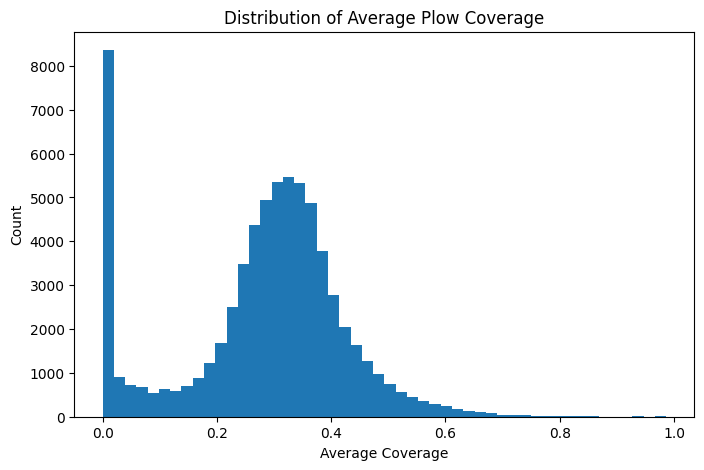

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(plow_df["average_coverage"].dropna(), bins=50)
plt.xlabel("Average Coverage")
plt.ylabel("Count")
plt.title("Distribution of Average Plow Coverage")
plt.show()


In [136]:
plow_df[plow_df["average_coverage"] < 0.1]

,normalized_street_name_season,snap_count,coverage,average_coverage
8,1-1 avenue loop_2018,1410,3.2,0.002270
9,1-1 avenue loop_2019,420,11.2,0.026667
10,1-1 avenue loop_2021,730,71.0,0.097260
14,1-1 drive_2017,460,0.0,0.000000
15,1-1 drive_2018,855,0.0,0.000000
...,...,...,...,...
69041,5-zarelli court_2017,153,0.0,0.000000
69042,5-zarelli court_2018,285,0.0,0.000000
69043,5-zarelli court_2019,84,0.0,0.000000
69044,5-zarelli court_2021,145,0.0,0.000000


In [57]:
# Ensure winter_year is string
plow_df['winter_year'] = plow_df['winter_year'].astype(str)

# Create unique identifier
plow_df['normalized_street_name_season'] = (
    plow_df['normalized_street_name'] + "_" + plow_df['winter_year']
)

# Optional: reorder columns so identifier is first
cols = ['normalized_street_name_season'] + [c for c in plow_df.columns if c not in ['normalized_street_name_season']]
plow_df = plow_df[cols]

# Optional: drop original columns
plow_df = plow_df.drop(columns=['normalized_street_name', 'winter_year'])


In [60]:
# Melt the dataframe: wide → long
snowfall_df = street_snowfall.melt(
    id_vars=['normalized_street_name', 'total_area'],
    value_vars=[f'snowfall {y}' for y in range(2016, 2026)],
    var_name='year_col',
    value_name='snowfall'
)

# Extract the year as integer from 'snowfall 20XX'
snowfall_df['year'] = snowfall_df['year_col'].str.replace('snowfall ', '').astype(int)

# Create normalized_street_name_season column
snowfall_df['normalized_street_name_season'] = (
    snowfall_df['normalized_street_name'] + "_" + snowfall_df['year'].astype(str)
)

# Keep only relevant columns
snowfall_df = snowfall_df[['normalized_street_name_season', 'normalized_street_name', 'year', 'total_area', 'snowfall']]

# Optional: sort
snowfall_df = snowfall_df.sort_values(['normalized_street_name', 'year']).reset_index(drop=True)


In [61]:
snowfall_df["snowfall_factor"] = snowfall_df["snowfall"]/snowfall_df["total_area"]
snowfall_df.head()

,normalized_street_name_season,normalized_street_name,year,total_area,snowfall,snowfall_factor
0,1-1 avenue_2016,1-1 avenue,2016,253446.943078,1.332371e+07,52.57
1,1-1 avenue_2017,1-1 avenue,2017,253446.943078,1.846868e+07,72.87
2,1-1 avenue_2018,1-1 avenue,2018,253446.943078,2.038474e+07,80.43
3,1-1 avenue_2019,1-1 avenue,2019,253446.943078,1.218826e+07,48.09
4,1-1 avenue_2020,1-1 avenue,2020,253446.943078,7.131997e+06,28.14


LINEAR REGRESSION snowfall -> resurfacing factor, each street-year is a data point

In [64]:
import pandas as pd
import statsmodels.api as sm

# --- 1. Filter for the years of interest ---
years_of_interest = [2017, 2018, 2019, 2021]

snowfall_filtered = snowfall_df[snowfall_df['year'].isin(years_of_interest)]
resurfacing_filtered = resurfacing_agg[resurfacing_agg['roadwork_season'].isin(years_of_interest)]

# --- 2. Merge on normalized_street_name_season ---
df_merged = pd.merge(
    snowfall_filtered,
    resurfacing_filtered,
    left_on='normalized_street_name_season',
    right_on='normalized_street_name_season',
    how='inner'  # only keep street-season pairs present in both
)

# --- 3. Define features and target ---
# Feature: snowfall scaled by total_area if desired
X = df_merged[['snowfall_factor']]  # or 'snowfall' * 'total_area' if that's your "road impact"
y = df_merged['roadwork_factor']  # column from resurfacing_agg

# Add constant for intercept
X = sm.add_constant(X)

# --- 4. Fit linear regression ---
model = sm.OLS(y, X).fit()

# --- 5. Output results ---
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        roadwork_factor   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.003326
Date:                Sun, 19 Oct 2025   Prob (F-statistic):              0.954
Time:                        16:00:05   Log-Likelihood:                -14182.
No. Observations:                3776   AIC:                         2.837e+04
Df Residuals:                    3774   BIC:                         2.838e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.7971      0.772     

In [133]:
import pandas as pd
import statsmodels.api as sm

# Years to consider
years_of_interest = [2017, 2018, 2019, 2021]

# Filter
snowfall_filtered = snowfall_df[snowfall_df['year'].isin(years_of_interest)]
resurfacing_filtered = resurfacing_agg[resurfacing_agg['roadwork_season'].isin(years_of_interest)]

# Identify missing entries
snowfall_keys = set(snowfall_filtered['normalized_street_name_season'])
resurfacing_keys = set(resurfacing_filtered['normalized_street_name_season'])

# Merge for regression
df_merged = pd.merge(
    snowfall_filtered,
    resurfacing_filtered,
    on='normalized_street_name_season',
    how='inner'
)

# Features and target
X = sm.add_constant(df_merged['snowfall'])
y = df_merged['roadwork_factor']

# Fit regression
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        roadwork_factor   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     20.50
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           6.14e-06
Time:                        12:48:39   Log-Likelihood:                -14172.
No. Observations:                3776   AIC:                         2.835e+04
Df Residuals:                    3774   BIC:                         2.836e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3881      0.207     11.536      0.0

In [134]:
only_in_snowfall = sorted(list(snowfall_keys - resurfacing_keys))
only_in_resurfacing = sorted(list(resurfacing_keys - snowfall_keys))

print("Present in snowfall_df but missing in resurfacing_agg:", len(only_in_snowfall), " of ", len(snowfall_filtered))
print("Present in resurfacing_agg but missing in snowfall_df:", len(only_in_resurfacing), " of ", len(resurfacing_filtered))

Present in snowfall_df but missing in resurfacing_agg: 44224  of  48000
Present in resurfacing_agg but missing in snowfall_df: 152  of  3928


for those entries in snowfall_df that do not have a corresponding entry in resurfacing_agg put value 0

In [69]:
import pandas as pd
import statsmodels.api as sm

years_of_interest = [2017, 2018, 2019, 2021]

# Filter
snowfall_filtered = snowfall_df[snowfall_df['year'].isin(years_of_interest)]
resurfacing_filtered = resurfacing_agg[resurfacing_agg['roadwork_season'].isin(years_of_interest)]

# Left merge so all snowfall rows are kept
df_merged = pd.merge(
    snowfall_filtered,
    resurfacing_filtered[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)

# Fill missing roadwork with 0
df_merged['roadwork_factor'] = df_merged['roadwork_factor'].fillna(0)

# Features and target
X = sm.add_constant(df_merged['snowfall'])
y = df_merged['roadwork_factor']

# Fit regression
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        roadwork_factor   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.457
Date:                Sun, 19 Oct 2025   Prob (F-statistic):             0.0630
Time:                        16:00:05   Log-Likelihood:            -1.1995e+05
No. Observations:               48000   AIC:                         2.399e+05
Df Residuals:                   47998   BIC:                         2.399e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1349      0.014      9.340      0.0

In [71]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# --- Filter years of interest ---
years_of_interest = [2017, 2018, 2019, 2021]

snowfall_filtered = snowfall_df[snowfall_df['year'].isin(years_of_interest)]
resurfacing_filtered = resurfacing_agg[resurfacing_agg['roadwork_season'].isin(years_of_interest)]

# --- Merge on normalized_street_name_season ---
df_merged = pd.merge(
    snowfall_filtered,
    resurfacing_filtered[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)

# --- Fill missing roadwork with 0 ---
df_merged['roadwork_factor'] = df_merged['roadwork_factor'].fillna(0)

# --- Transform outcome to reduce skewness ---
df_merged['log_roadwork'] = np.log1p(df_merged['roadwork_factor'])  # log(roadwork + 1)

# --- Regression ---
X = sm.add_constant(df_merged['snowfall'])  # predictor
y = df_merged['log_roadwork']               # log-transformed outcome

model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           log_roadwork   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     405.3
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           9.17e-90
Time:                        16:00:05   Log-Likelihood:                -2257.0
No. Observations:               48000   AIC:                             4518.
Df Residuals:                   47998   BIC:                             4536.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0438      0.001     35.176      0.0

In [128]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Merge datasets on normalized_street_name_season ---
df_merged = pd.merge(
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor', 'area', 'sqyd-days']],
    snowfall_df[['normalized_street_name_season', 'snowfall', 'total_area']],
    on='normalized_street_name_season',
    how='left'
)

# --- Fill missing snowfall and total_area with 0 ---
df_merged[['snowfall', 'total_area']] = df_merged[['snowfall', 'total_area']].fillna(0)

# --- Ensure nonnegative values ---
for c in ['roadwork_factor', 'sqyd-days', 'total_area', 'snowfall']:
    df_merged[c] = df_merged[c].clip(lower=0)
    df_merged[c].replace([np.inf, -np.inf], np.nan, inplace=True)

# --- Apply log1p transforms ---
df_merged['log_roadwork_factor'] = np.log1p(df_merged['roadwork_factor'])
df_merged['log_total_area'] = np.log1p(df_merged['total_area'])
df_merged['log_snowfall'] = np.log1p(df_merged['snowfall'])

# --- Drop NaN rows in key columns ---
df_clean = df_merged.dropna(subset=['log_roadwork_factor', 'log_total_area', 'log_snowfall'])

# --- Define regression model: log(roadwork_factor) ~ log(total_area) + log(snowfall) ---
X = df_clean[['log_total_area', 'log_snowfall']]
y = df_clean['log_roadwork_factor']

# Add constant term
X = sm.add_constant(X)

# --- Fit OLS regression ---
model = sm.OLS(y, X).fit(cov_type='HC3')  # robust SEs

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     log_roadwork_factor   R-squared:                       0.123
Model:                             OLS   Adj. R-squared:                  0.123
Method:                  Least Squares   F-statistic:                     448.8
Date:                 Tue, 21 Oct 2025   Prob (F-statistic):          2.72e-188
Time:                         10:45:28   Log-Likelihood:                -9008.0
No. Observations:                11333   AIC:                         1.802e+04
Df Residuals:                    11330   BIC:                         1.804e+04
Df Model:                            2                                         
Covariance Type:                   HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.4498      0.0

/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/2625197952.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged[c].replace([np.inf, -np.inf], np.nan, inplace=True)
/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/2625197952.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are settin

impute average plow coverage from similarly sized streets

In [96]:
import pandas as pd
import numpy as np

# Merge plow_df with snowfall_df to ensure all streets are included
df = pd.merge(
    snowfall_df[['normalized_street_name_season', 'total_area']],
    plow_df[['normalized_street_name_season', 'average_coverage']],
    on='normalized_street_name_season',
    how='left'
)

# Bin streets by total_area
num_bins = 20
df['area_bin'] = pd.qcut(df['total_area'], q=num_bins, duplicates='drop')

# Convert bins to strings for safe mapping
df['area_bin_str'] = df['area_bin'].astype(str)

# Compute median average_coverage for each area bin
median_by_bin = df.groupby('area_bin_str')['average_coverage'].median().to_dict()

# Identify missing average_coverage
missing_mask = df['average_coverage'].isna()

# Impute missing values
df.loc[missing_mask, 'average_coverage'] = df.loc[missing_mask, 'area_bin_str'].map(median_by_bin)

# Optional: fill any remaining NaNs with 0
df['average_coverage'] = df['average_coverage'].fillna(0)

# Drop helper columns
df = df.drop(columns=['area_bin', 'area_bin_str'])


In [130]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Merge data ---
df_model = pd.merge(
    snowfall_df[['normalized_street_name_season', 'snowfall', 'total_area']],
    plow_df[['normalized_street_name_season', 'average_coverage']],
    on='normalized_street_name_season',
    how='left'
)

df_model = pd.merge(
    df_model,
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)

# Drop rows missing target
df_model = df_model.dropna(subset=['roadwork_factor'])

# --- Replace negative values with zero (log1p cannot handle negatives) ---
for col in ['snowfall', 'total_area', 'average_coverage', 'roadwork_factor']:
    df_model[col] = df_model[col].clip(lower=0)

# --- Apply log1p transform with new column names ---
for col in ['snowfall', 'total_area', 'average_coverage', 'roadwork_factor']:
    df_model[f'log_{col}'] = np.log1p(df_model[col])

# --- Remove any remaining rows with inf or NaN in log columns ---
log_cols = ['log_snowfall', 'log_total_area', 'log_average_coverage', 'log_roadwork_factor']
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=log_cols)

# --- Fit linear model ---
X = sm.add_constant(df_model[['log_snowfall', 'log_average_coverage', 'log_total_area']])
y = df_model['log_roadwork_factor']

model = sm.OLS(y, X).fit()

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     log_roadwork_factor   R-squared:                       0.217
Model:                             OLS   Adj. R-squared:                  0.216
Method:                  Least Squares   F-statistic:                     490.6
Date:                 Tue, 21 Oct 2025   Prob (F-statistic):          1.75e-281
Time:                         10:48:28   Log-Likelihood:                -4181.2
No. Observations:                 5327   AIC:                             8370.
Df Residuals:                     5323   BIC:                             8397.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

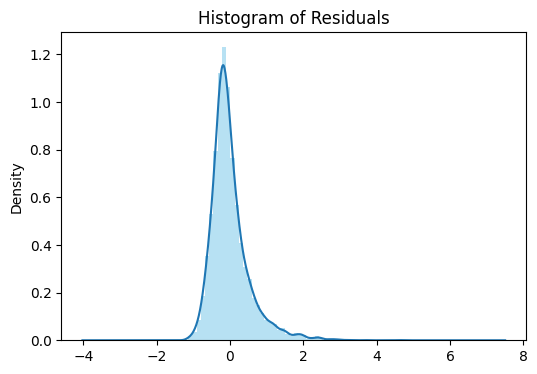

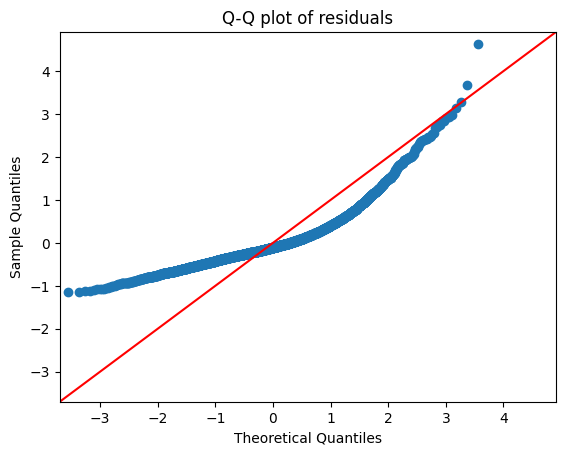

Shapiro-Wilk test: ShapiroResult(statistic=np.float64(0.8752443380455759), pvalue=np.float64(3.374632038812588e-54))
Kolmogorov-Smirnov test: KstestResult(statistic=np.float64(0.121927697602215), pvalue=np.float64(1.7911113752700515e-69), statistic_location=np.float64(0.19653262888359066), statistic_sign=np.int8(1))


/Users/aleksandarmilivojevic/Downloads/python_folder_vs_code/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5327.
  res = hypotest_fun_out(*samples, **kwds)


In [131]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Extract residuals
residuals = model.resid

# 1. Histogram / density plot
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50, density=True, alpha=0.6, color='skyblue')
residuals.plot(kind='kde')
plt.title("Histogram of Residuals")
plt.show()

# 2. Q-Q plot (compare to theoretical normal)
sm.qqplot(residuals, line='45')
plt.title("Q-Q plot of residuals")
plt.show()

# 3. Statistical tests
shapiro_test = stats.shapiro(residuals)
print("Shapiro-Wilk test:", shapiro_test)

kstest = stats.kstest((residuals - residuals.mean())/residuals.std(), 'norm')
print("Kolmogorov-Smirnov test:", kstest)


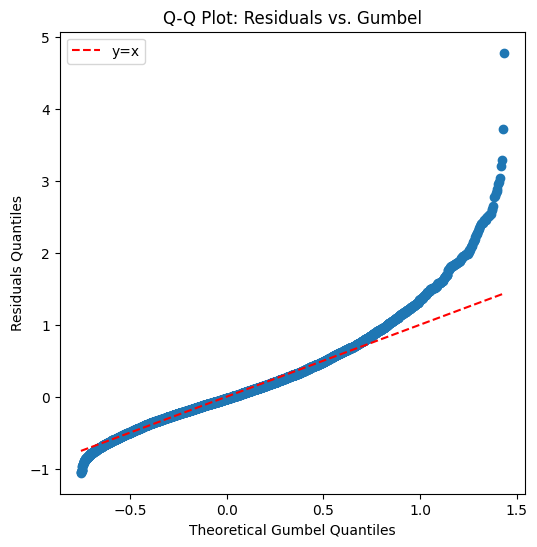

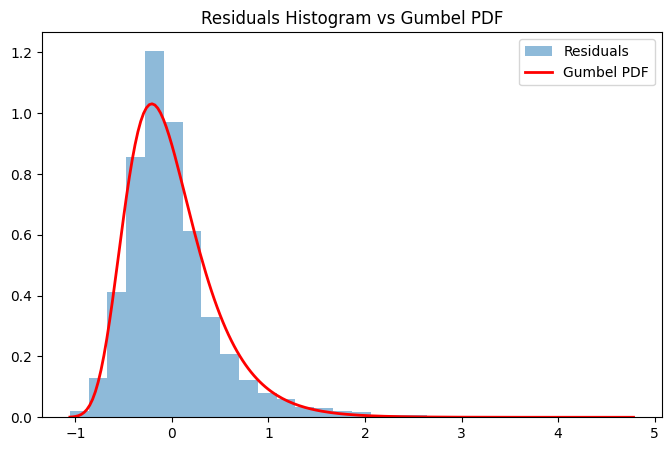

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# residuals from your fitted model
resid = model.resid

# Fit a Gumbel distribution to residuals
params = stats.gumbel_r.fit(resid)  # returns (loc, scale)

# Generate theoretical Gumbel values for Q-Q plot
theoretical = stats.gumbel_r.ppf(
    np.linspace(0.01, 0.99, len(resid)), *params
)
sorted_resid = np.sort(resid)

# Q-Q plot
plt.figure(figsize=(6,6))
plt.plot(theoretical, sorted_resid, 'o')
plt.plot(theoretical, theoretical, 'r--', label='y=x')
plt.xlabel('Theoretical Gumbel Quantiles')
plt.ylabel('Residuals Quantiles')
plt.title('Q-Q Plot: Residuals vs. Gumbel')
plt.legend()
plt.show()

# Histogram comparison
plt.figure(figsize=(8,5))
plt.hist(resid, bins=30, density=True, alpha=0.5, label='Residuals')
x = np.linspace(resid.min(), resid.max(), 200)
plt.plot(x, stats.gumbel_r.pdf(x, *params), 'r-', lw=2, label='Gumbel PDF')
plt.title('Residuals Histogram vs Gumbel PDF')
plt.legend()
plt.show()


Fitted lognormal parameters: shape=0.4815, scale=0.9568, shift applied=1.0569


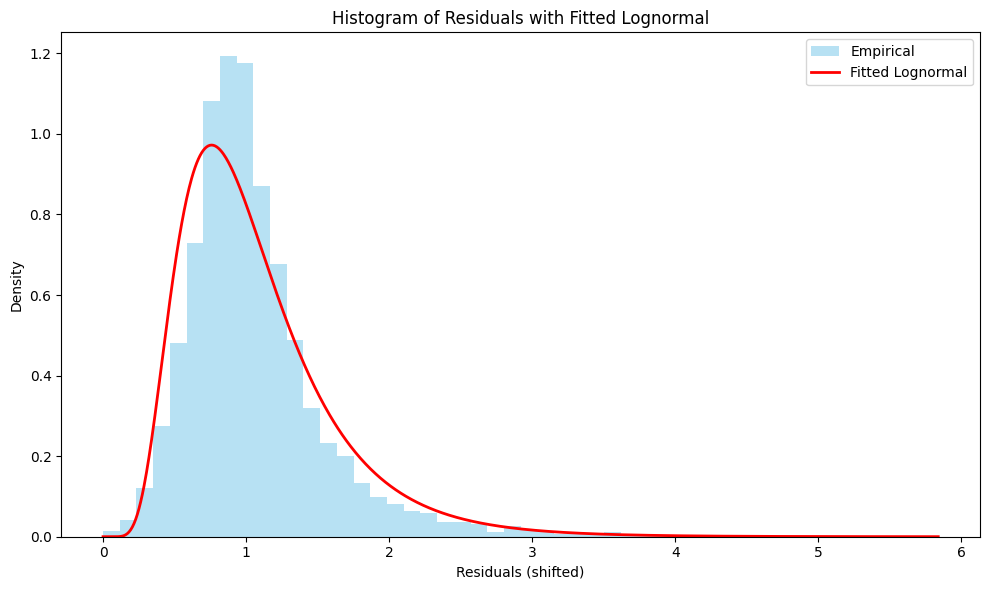

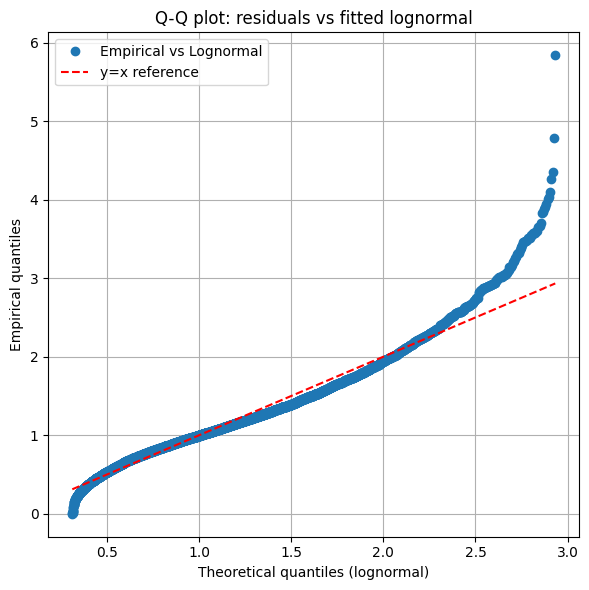

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# --- Assume `residuals` is your 1D array of residuals ---
residuals = residuals[np.isfinite(residuals)]  # remove nan/inf

# --- Shift residuals if necessary (lognormal requires positive values) ---
shift = 0
if residuals.min() <= 0:
    shift = abs(residuals.min()) + 1e-6
    residuals_shifted = residuals + shift
else:
    residuals_shifted = residuals

# --- Fit lognormal distribution ---
shape, loc, scale = lognorm.fit(residuals_shifted, floc=0)  # fix loc=0
print(f"Fitted lognormal parameters: shape={shape:.4f}, scale={scale:.4f}, shift applied={shift:.4f}")

# --- Histogram with fitted lognormal PDF ---
x = np.linspace(residuals_shifted.min(), residuals_shifted.max(), 1000)
pdf_fitted = lognorm.pdf(x, shape, loc=0, scale=scale)

plt.figure(figsize=(10,6))
plt.hist(residuals_shifted, bins=50, density=True, alpha=0.6, color='skyblue', label='Empirical')
plt.plot(x, pdf_fitted, 'r-', lw=2, label='Fitted Lognormal')
plt.xlabel("Residuals (shifted)" if shift>0 else "Residuals")
plt.ylabel("Density")
plt.title("Histogram of Residuals with Fitted Lognormal")
plt.legend()
plt.tight_layout()
plt.show()

# --- Q-Q plot against fitted lognormal ---
theoretical_quantiles = lognorm.ppf(
    np.linspace(0.01, 0.99, len(residuals_shifted)), shape, loc=0, scale=scale
)
empirical_quantiles = np.sort(residuals_shifted)

plt.figure(figsize=(6,6))
plt.plot(theoretical_quantiles, empirical_quantiles, 'o', label="Empirical vs Lognormal")
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--', label="y=x reference")
plt.xlabel("Theoretical quantiles (lognormal)")
plt.ylabel("Empirical quantiles")
plt.title("Q-Q plot: residuals vs fitted lognormal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


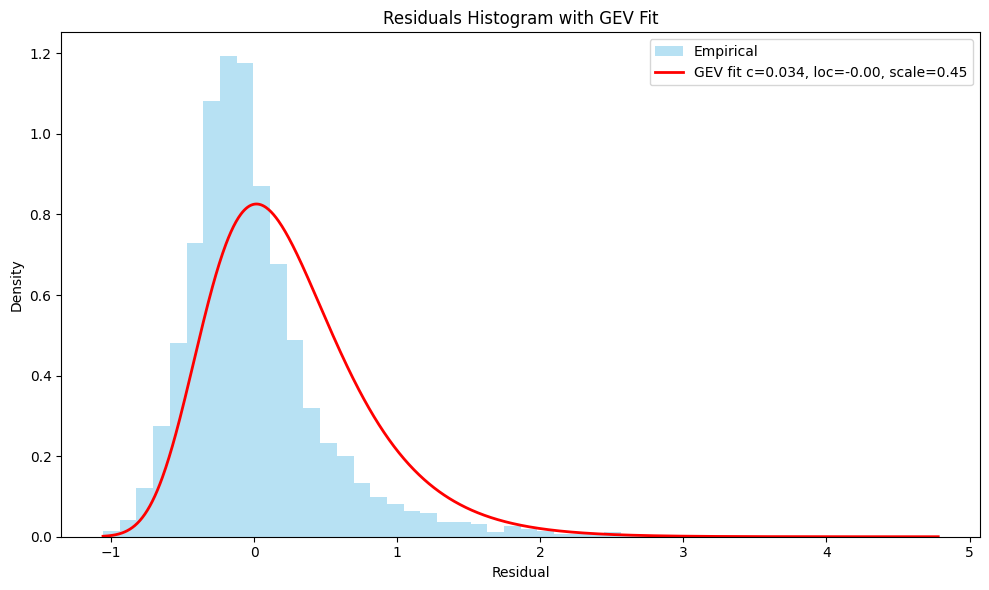

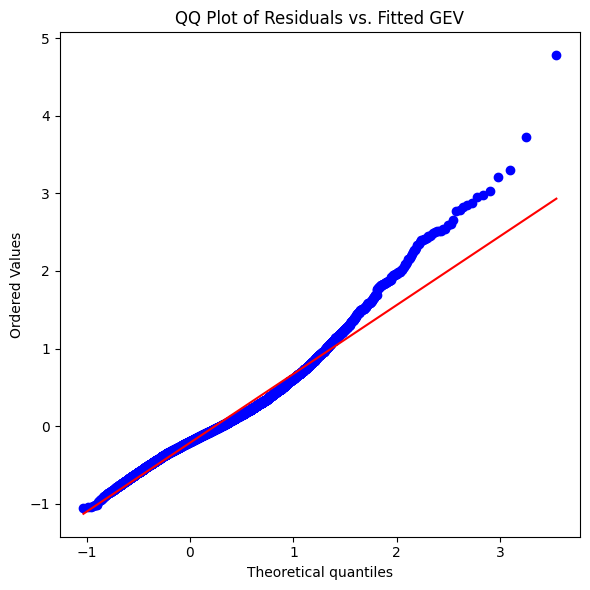

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, probplot

# --- Suppose residuals are in a series called 'residuals' ---
# Example: residuals = fitted_model.resid

# Keep only finite residuals
residuals = residuals[np.isfinite(residuals)]

# --- Fit GEV distribution ---
c, loc, scale = genextreme.fit(residuals)

# --- Histogram with GEV PDF overlay ---
x = np.linspace(residuals.min(), residuals.max(), 1000)
pdf_fitted = genextreme.pdf(x, c, loc=loc, scale=scale)

plt.figure(figsize=(10,6))
plt.hist(residuals, bins=50, density=True, alpha=0.6, color='skyblue', label='Empirical')
plt.plot(x, pdf_fitted, 'r-', lw=2, label=f'GEV fit c={c:.3f}, loc={loc:.2f}, scale={scale:.2f}')
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Residuals Histogram with GEV Fit")
plt.legend()
plt.tight_layout()
plt.show()

# --- QQ plot against fitted GEV ---
plt.figure(figsize=(6,6))
probplot(residuals, dist=genextreme, sparams=(c, loc, scale), plot=plt)
plt.title("QQ Plot of Residuals vs. Fitted GEV")
plt.tight_layout()
plt.show()


RUN LINEAR REGRESSION

In [184]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Merge datasets on normalized_street_name_season ---
df_model = resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']].merge(
    snowfall_df[['normalized_street_name_season', 'snowfall_factor']],
    on='normalized_street_name_season',
    how='inner'  # only keep rows present in both
).merge(
    plow_df[['normalized_street_name_season', 'average_coverage']],
    on='normalized_street_name_season',
    how='inner'
)

# --- Remove invalid values ---
for col in ['roadwork_factor', 'snowfall_factor', 'average_coverage']:
    df_model[col].replace([np.inf, -np.inf], np.nan, inplace=True)

df_model.dropna(subset=['roadwork_factor', 'snowfall_factor', 'average_coverage'], inplace=True)

# --- Remove extreme outliers (IQR method) ---
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series >= lower) & (series <= upper)].index

valid_idx = df_model.index
for col in ['roadwork_factor', 'snowfall_factor', 'average_coverage']:
    valid_idx = valid_idx.intersection(remove_outliers(df_model[col]))

df_model = df_model.loc[valid_idx]

# --- Regression 1: roadwork_factor ~ snowfall_factor ---
X1 = sm.add_constant(df_model[['snowfall_factor']])
y = df_model['roadwork_factor']
model1 = sm.OLS(y, X1).fit()
print("Regression 1: roadwork_factor ~ snowfall_factor")
print(model1.summary2())

# --- Regression 2: roadwork_factor ~ snowfall_factor + average_coverage ---
X2 = sm.add_constant(df_model[['snowfall_factor', 'average_coverage']])
model2 = sm.OLS(y, X2).fit()
print("\nRegression 2: roadwork_factor ~ snowfall_factor + average_coverage")
print(model2.summary2())


Regression 1: roadwork_factor ~ snowfall_factor
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.011    
Dependent Variable: roadwork_factor  AIC:                8916.1929
Date:               2025-10-22 15:29 BIC:                8929.0571
No. Observations:   4592             Log-Likelihood:     -4456.1  
Df Model:           1                F-statistic:        52.87    
Df Residuals:       4590             Prob (F-statistic): 4.17e-13 
R-squared:          0.011            Scale:              0.40794  
-------------------------------------------------------------------
                  Coef.   Std.Err.     t     P>|t|   [0.025  0.975]
-------------------------------------------------------------------
const             0.3759    0.0368  10.2224  0.0000  0.3038  0.4480
snowfall_factor   0.0041    0.0006   7.2711  0.0000  0.0030  0.0052
------------------------------------------------------------------
Omnibus:              852.5

/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/1801391720.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].replace([np.inf, -np.inf], np.nan, inplace=True)


now with log...

In [185]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Merge datasets on normalized_street_name_season ---
df_model = resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']].merge(
    snowfall_df[['normalized_street_name_season', 'snowfall_factor']],
    on='normalized_street_name_season',
    how='inner'
).merge(
    plow_df[['normalized_street_name_season', 'average_coverage']],
    on='normalized_street_name_season',
    how='inner'
)

# --- Replace invalid values and drop ---
for col in ['roadwork_factor', 'snowfall_factor', 'average_coverage']:
    df_model[col].replace([np.inf, -np.inf], np.nan, inplace=True)

df_model.dropna(subset=['roadwork_factor', 'snowfall_factor', 'average_coverage'], inplace=True)

# --- Apply log1p to all columns ---
df_model['log_roadwork_factor'] = np.log1p(df_model['roadwork_factor'])
df_model['log_snowfall_factor'] = np.log1p(df_model['snowfall_factor'])
df_model['log_average_coverage'] = np.log1p(df_model['average_coverage'])

# --- Remove extreme outliers (IQR) on log-transformed columns ---
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series >= lower) & (series <= upper)].index

valid_idx = df_model.index
for col in ['log_roadwork_factor', 'log_snowfall_factor', 'log_average_coverage']:
    valid_idx = valid_idx.intersection(remove_outliers(df_model[col]))

df_model = df_model.loc[valid_idx]

# --- Regression 1: log_roadwork_factor ~ log_snowfall_factor ---
X1 = sm.add_constant(df_model[['log_snowfall_factor']])
y = df_model['log_roadwork_factor']
model1 = sm.OLS(y, X1).fit()
print("Regression 1: log_roadwork_factor ~ log_snowfall_factor")
print(model1.summary2())

# --- Regression 2: log_roadwork_factor ~ log_snowfall_factor + log_average_coverage ---
X2 = sm.add_constant(df_model[['log_snowfall_factor', 'log_average_coverage']])
model2 = sm.OLS(y, X2).fit()
print("\nRegression 2: log_roadwork_factor ~ log_snowfall_factor + log_average_coverage")
print(model2.summary2())


Regression 1: log_roadwork_factor ~ log_snowfall_factor
                   Results: Ordinary least squares
Model:              OLS                 Adj. R-squared:     0.012    
Dependent Variable: log_roadwork_factor AIC:                5404.8558
Date:               2025-10-22 15:29    BIC:                5417.8391
No. Observations:   4874                Log-Likelihood:     -2700.4  
Df Model:           1                   F-statistic:        62.08    
Df Residuals:       4872                Prob (F-statistic): 4.04e-15 
R-squared:          0.013               Scale:              0.17740  
---------------------------------------------------------------------
                       Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
---------------------------------------------------------------------
const                 -0.2499   0.0935 -2.6717 0.0076 -0.4333 -0.0665
log_snowfall_factor    0.1780   0.0226  7.8791 0.0000  0.1337  0.2223
-----------------------------------------------------

/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/3840376037.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].replace([np.inf, -np.inf], np.nan, inplace=True)


adding in average_snap_count column to plow_df

In [189]:
plow_df.columns

Index(['normalized_street_name_season', 'snap_count', 'coverage',
       'average_coverage', 'total_area_x', 'average_snap_count',
       'total_area_y'],
      dtype='object')

In [191]:
# Compute average_snap_count directly
plow_df['average_snap_count'] = plow_df['snap_count'] / plow_df['total_area']

# Handle any division issues
plow_df['average_snap_count'].replace([np.inf, -np.inf], np.nan, inplace=True)
plow_df['average_snap_count'].fillna(0, inplace=True)


/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/3476142950.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  plow_df['average_snap_count'].replace([np.inf, -np.inf], np.nan, inplace=True)
/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/3476142950.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on whic

In [192]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Merge datasets ---
df_model = resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']].merge(
    snowfall_df[['normalized_street_name_season', 'snowfall_factor', 'total_area']],
    on='normalized_street_name_season',
    how='inner'
).merge(
    plow_df[['normalized_street_name_season', 'average_coverage', 'average_snap_count']],
    on='normalized_street_name_season',
    how='inner'
)

# --- Remove invalid values ---
for col in ['roadwork_factor', 'snowfall_factor', 'average_coverage', 'average_snap_count']:
    df_model[col].replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.dropna(subset=['roadwork_factor', 'snowfall_factor', 'average_coverage', 'average_snap_count'], inplace=True)

# --- Remove extreme outliers (IQR) ---
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return series[(series >= lower) & (series <= upper)].index

valid_idx = df_model.index
for col in ['roadwork_factor', 'snowfall_factor', 'average_coverage', 'average_snap_count']:
    valid_idx = valid_idx.intersection(remove_outliers(df_model[col]))
df_model = df_model.loc[valid_idx]

# ------------------------------
# 1. Linear regression on normal data
# ------------------------------
X_norm = sm.add_constant(df_model[['snowfall_factor', 'average_coverage', 'average_snap_count']])
y_norm = df_model['roadwork_factor']
model_norm = sm.OLS(y_norm, X_norm).fit()
print("OLS regression on normal data:")
print(model_norm.summary2())

# ------------------------------
# 2. Linear regression on log1p-transformed data
# ------------------------------
df_model['log_roadwork_factor'] = np.log1p(df_model['roadwork_factor'])
df_model['log_snowfall_factor'] = np.log1p(df_model['snowfall_factor'])
df_model['log_average_coverage'] = np.log1p(df_model['average_coverage'])
df_model['log_average_snap_count'] = np.log1p(df_model['average_snap_count'])

X_log = sm.add_constant(df_model[['log_snowfall_factor', 'log_average_coverage', 'log_average_snap_count']])
y_log = df_model['log_roadwork_factor']
model_log = sm.OLS(y_log, X_log).fit()
print("\nOLS regression on log1p-transformed data:")
print(model_log.summary2())


OLS regression on normal data:
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.014    
Dependent Variable: roadwork_factor  AIC:                8321.9723
Date:               2025-10-22 15:34 BIC:                8347.5133
No. Observations:   4382             Log-Likelihood:     -4157.0  
Df Model:           3                F-statistic:        21.41    
Df Residuals:       4378             Prob (F-statistic): 9.24e-14 
R-squared:          0.014            Scale:              0.39076  
------------------------------------------------------------------
                    Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
------------------------------------------------------------------
const               0.6211   0.0623  9.9648 0.0000  0.4989  0.7433
snowfall_factor     0.0019   0.0007  2.6697 0.0076  0.0005  0.0033
average_coverage   -0.5479   0.1408 -3.8902 0.0001 -0.8240 -0.2718
average_snap_count  0.6492   0.2141  3.0320 0.002

/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/4183587858.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].replace([np.inf, -np.inf], np.nan, inplace=True)


START USING STREET_WEATHER INSTEAD OF SNOWFALL

In [198]:
street_weather = pd.read_csv("street_weather.csv")

In [267]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Step 1: Base is street_weather ---
df_model = street_weather.copy()
df_model = df_model[['normalized_street_name_season', 'apparent_temperature', 'cloud_cover',
                     'precipitation', 'relative_humidity', 'snow_depth', 'snowfall',
                     'temperature', 'wind_gusts_10m', 'wind_speed_10m']]

# --- Step 2: Merge roadwork data, fill missing with 0 ---
df_model = df_model.merge(
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)
df_model['roadwork_factor'] = df_model['roadwork_factor'].fillna(0)

# --- Step 3: Merge plow data, fill missing with 0 ---
df_model = df_model.merge(
    plow_df[['normalized_street_name_season', 'average_coverage', 'average_snap_count']],
    on='normalized_street_name_season',
    how='left'
)
df_model['average_coverage'] = df_model['average_coverage'].fillna(0)
df_model['average_snap_count'] = df_model['average_snap_count'].fillna(0)

# --- Step 4: Filter only desired seasons ---
valid_seasons = ['2017', '2018', '2019', '2021']
df_model = df_model[df_model['normalized_street_name_season'].astype(str).str[-4:].isin(valid_seasons)]

# --- Step 5: Create binary target ---
df_model['roadwork_done'] = (df_model['roadwork_factor'] > 0).astype(int)

# --- Step 6: Define predictors ---
predictors = [
    'average_coverage', #'average_snap_count', 
    #'apparent_temperature', 'cloud_cover',
    #'precipitation', 'relative_humidity', 'snow_depth', 'snowfall',
    #'temperature', 'wind_gusts_10m', 'wind_speed_10m'
]

# --- Step 7: Train/test split (stratified!) ---
X = df_model[predictors]
y = df_model['roadwork_done']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Step 8: Fit classifier ---
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# --- Step 9: Evaluate ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# --- Step 10: Feature importances ---
importances = pd.DataFrame({
    'feature': predictors,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)


              precision    recall  f1-score   support

           0       0.93      0.91      0.92     13267
           1       0.12      0.14      0.13      1133

    accuracy                           0.85     14400
   macro avg       0.52      0.53      0.52     14400
weighted avg       0.86      0.85      0.86     14400

[[12075  1192]
 [  973   160]]
            feature  importance
0  average_coverage         1.0


bring street type into the mix

In [268]:
cscl.columns

Index(['PHYSICALID', 'normalized_street_name', 'Segment Length',
       'Street Width', 'nearest_station'],
      dtype='object')

In [283]:
cscl['street_type'] = cscl['street_type'].fillna('missing')


In [290]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Step 1: Base is street_weather ---
df_model = street_weather.copy()
df_model = df_model[['normalized_street_name_season', 'apparent_temperature', 'cloud_cover',
                     'precipitation', 'relative_humidity', 'snow_depth', 'snowfall',
                     'temperature', 'wind_gusts_10m', 'wind_speed_10m']]

# --- Step 2: Merge roadwork data, fill missing with 0 ---
df_model = df_model.merge(
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)
df_model['roadwork_factor'] = df_model['roadwork_factor'].fillna(0)

# --- Step 3: Merge plow data, fill missing with 0 ---
df_model = df_model.merge(
    plow_df[['normalized_street_name_season', 'average_coverage', 'average_snap_count']],
    on='normalized_street_name_season',
    how='left'
)
df_model['average_coverage'] = df_model['average_coverage'].fillna(0)
df_model['average_snap_count'] = df_model['average_snap_count'].fillna(0)

# --- Step 4: Filter only desired seasons ---
valid_seasons = ['2017', '2018', '2019', '2021']
df_model = df_model[df_model['normalized_street_name_season'].astype(str).str[-4:].isin(valid_seasons)]

# --- Step 5: Create binary target ---
df_model['roadwork_done'] = (df_model['roadwork_factor'] > 0).astype(int)

# --- Step 6: Map street_type from cscl ---
df_model['normalized_street_name'] = df_model['normalized_street_name_season'].str[:-5]
# Create a mapping from normalized_street_name to street_type
street_type_map = cscl.drop_duplicates(subset=['normalized_street_name']).set_index('normalized_street_name')['street_type']

# Add street_type to df_model
df_model['normalized_street_name'] = df_model['normalized_street_name_season'].str[:-5]  # remove season
df_model['street_type'] = df_model['normalized_street_name'].map(street_type_map)

# --- Step 7: Encode street_type ---
df_model = pd.get_dummies(df_model, columns=['street_type'], dummy_na=True)

# --- Step 8: Define predictors ---
predictors = [
    'average_coverage',
    'average_snap_count',
    'apparent_temperature', 'cloud_cover',
    'precipitation', 'relative_humidity', 'snow_depth', 'snowfall',
    'temperature', 'wind_gusts_10m', 'wind_speed_10m'
] + [c for c in df_model.columns if c.startswith('street_type_')]

# --- Step 9: Train/test split (stratified) ---
X = df_model[predictors]
y = df_model['roadwork_done']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Step 10: Fit classifier ---
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# --- Step 11: Evaluate ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# --- Step 12: Feature importances ---
importances = pd.DataFrame({
    'feature': predictors,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     13267
           1       0.21      0.06      0.10      1133

    accuracy                           0.91     14400
   macro avg       0.57      0.52      0.53     14400
weighted avg       0.87      0.91      0.88     14400

[[13000   267]
 [ 1060    73]]
                feature    importance
0      average_coverage  3.976638e-01
1    average_snap_count  3.557702e-01
82  street_type_missing  4.571715e-02
69       street_type_ST  2.504280e-02
13      street_type_AVE  2.422919e-02
..                  ...           ...
34      street_type_EST  3.664059e-07
59       street_type_PT  2.284700e-07
70     street_type_STWY  1.294991e-07
17     street_type_BRDG  1.145185e-09
83      street_type_nan  0.000000e+00

[84 rows x 2 columns]


In [282]:
len(cscl)

122019

In [281]:
cscl[cscl['street_type'].isna()]

,PHYSICALID,normalized_street_name,Segment Length,Street Width,nearest_station,street_type
14,134995,1-randalls island greenway,NaN,20.0,4,NaN
17,176859,5-pedestrian and bike path link,350.663441,NaN,6,NaN
18,165466,4-van wyck expressway entrance nb,41.227458,42.0,3,NaN
40,106285,3-alley,44.095908,16.0,1,NaN
67,78511,2-major deegan expwy sb et 7 south,163.804528,25.0,5,NaN
...,...,...,...,...,...,...
121966,128931,2-hutchinson rvr parkway et 1b sb,143.752312,18.0,5,NaN
121967,174853,3-tillary street bike path,300.898419,NaN,1,NaN
121971,174855,3-tillary street bike path,314.071369,NaN,1,NaN
121998,205928,2-bruckner boulevard bike path,33.250208,NaN,5,NaN


In [295]:
unique_seasons = resurfacing_agg['normalized_street_name_season'].astype(str).str[-4:].unique()
print(unique_seasons)


['2016' '2019' '2020' '2022' '2024' '2017' '2021' '2018' '2025' '2023']


In [296]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Step 1: Filter seasons 2016-2023 ---
df_model = street_weather.copy()
df_model = df_model[df_model['normalized_street_name_season'].astype(str).str[-4:].isin([str(y) for y in range(2016, 2024)])]

# --- Step 2: Select weather columns ---
weather_features = [
    'apparent_temperature', 'cloud_cover', 'precipitation', 'relative_humidity',
    'snow_depth', 'snowfall', 'temperature', 'wind_gusts_10m', 'wind_speed_10m'
]
df_model = df_model[['normalized_street_name_season'] + weather_features]

# --- Step 3: Merge resurfacing data and create target ---
df_model = df_model.merge(
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)
df_model['roadwork_factor'] = df_model['roadwork_factor'].fillna(0)
df_model['roadwork_done'] = (df_model['roadwork_factor'] > 0).astype(int)

# --- Step 4: Define predictors and target ---
X = df_model[weather_features]
y = df_model['roadwork_done']

# --- Step 5: Train/test split (stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Step 6: Fit classifier ---
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# --- Step 7: Evaluate ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# --- Step 8: Feature importances ---
importances = pd.DataFrame({
    'feature': weather_features,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)


              precision    recall  f1-score   support

           0       0.94      0.51      0.66     26210
           1       0.12      0.66      0.20      2590

    accuracy                           0.53     28800
   macro avg       0.53      0.59      0.43     28800
weighted avg       0.86      0.53      0.62     28800

[[13451 12759]
 [  888  1702]]
                feature  importance
7        wind_gusts_10m    0.212766
1           cloud_cover    0.167908
8        wind_speed_10m    0.128275
0  apparent_temperature    0.118162
4            snow_depth    0.096192
2         precipitation    0.082339
3     relative_humidity    0.075896
5              snowfall    0.060072
6           temperature    0.058390


In [303]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Step 1: Base is street_weather ---
df_model = street_weather.copy()
df_model = df_model[['normalized_street_name_season', 'apparent_temperature', 'cloud_cover',
                     'precipitation', 'relative_humidity', 'snow_depth', 'snowfall',
                     'temperature', 'wind_gusts_10m', 'wind_speed_10m']]

# --- Step 2: Merge resurfacing data ---
df_model = df_model.merge(
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)
df_model['roadwork_factor'] = df_model['roadwork_factor'].fillna(0)

# --- Step 3: Filter only desired seasons (2016-2023) ---
valid_seasons = [str(y) for y in range(2016, 2024)]
df_model = df_model[df_model['normalized_street_name_season'].str[-4:].isin(valid_seasons)]

# --- Step 4: Map street_type from cscl ---
# cscl already has NaN handled as 'missing'
street_type_map = cscl.drop_duplicates(subset=['normalized_street_name']).set_index('normalized_street_name')['street_type']
df_model['normalized_street_name'] = df_model['normalized_street_name_season'].str[:-5]
df_model['street_type'] = df_model['normalized_street_name'].map(street_type_map)

# --- Step 5: One-hot encode street_type ---
df_model = pd.get_dummies(df_model, columns=['street_type'], prefix='street_type')

# --- Step 6: Create binary target ---
df_model['roadwork_done'] = (df_model['roadwork_factor'] > 0).astype(int)

# --- Step 7: Define predictors ---
predictors = [
    'apparent_temperature', 'cloud_cover', 'precipitation', 'relative_humidity',
    'snow_depth', 'snowfall', 'temperature', 'wind_gusts_10m', 'wind_speed_10m'
] + [c for c in df_model.columns if c.startswith('street_type_')]

# --- Step 8: Train/test split (stratified) ---
X = df_model[predictors]
y = df_model['roadwork_done']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Step 9: Fit classifier ---
clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    class_weight={0: 1, 1: 10}  # increase weight of minority class
)
clf.fit(X_train, y_train)

# --- Step 10: Evaluate ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# --- Step 11: Feature importances ---
importances = pd.DataFrame({
    'feature': predictors,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)


              precision    recall  f1-score   support

           0       0.96      0.65      0.77     26210
           1       0.17      0.75      0.28      2590

    accuracy                           0.66     28800
   macro avg       0.57      0.70      0.53     28800
weighted avg       0.89      0.66      0.73     28800

[[16973  9237]
 [  657  1933]]
                feature  importance
80  street_type_missing    0.188863
67       street_type_ST    0.155893
11      street_type_AVE    0.130028
7        wind_gusts_10m    0.056317
24       street_type_CT    0.049698
..                  ...         ...
25      street_type_CTR    0.000000
23     street_type_CRSE    0.000000
21       street_type_CP    0.000000
19     street_type_CMNS    0.000000
48      street_type_MNR    0.000000

[81 rows x 2 columns]


introduce lag

In [304]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Step 1: Base (weather) ---
df_model = street_weather.copy()
df_model = df_model[['normalized_street_name_season', 'apparent_temperature', 'cloud_cover',
                     'precipitation', 'relative_humidity', 'snow_depth', 'snowfall',
                     'temperature', 'wind_gusts_10m', 'wind_speed_10m']]

# --- Step 2: Add roadwork (fill missing with 0) ---
df_model = df_model.merge(
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)
df_model['roadwork_factor'] = df_model['roadwork_factor'].fillna(0)
df_model['roadwork_done'] = (df_model['roadwork_factor'] > 0).astype(int)

# --- Step 3: Limit to 2016–2024 seasons ---
df_model = df_model[df_model['normalized_street_name_season'].str[-4:].astype(int).between(2016, 2024)]

# --- Step 4: Add normalized_street_name and season ---
df_model['normalized_street_name'] = df_model['normalized_street_name_season'].str[:-5]
df_model['season'] = df_model['normalized_street_name_season'].str[-4:].astype(int)

# --- Step 5: Add street_type ---
street_type_map = cscl.drop_duplicates(subset=['normalized_street_name']).set_index('normalized_street_name')['street_type']
df_model['street_type'] = df_model['normalized_street_name'].map(street_type_map)

# --- Step 6: One-hot encode street_type ---
df_model = pd.get_dummies(df_model, columns=['street_type'], prefix='street_type')

# --- Step 7: Generate lag features (1-year and 2-year) ---
lags = []
for lag in [1, 2]:
    lagged = df_model.copy()
    lagged['season'] += lag
    lagged = lagged.rename(columns={
        c: f'{c}_lag{lag}' for c in [
            'roadwork_done', 'snow_depth', 'precipitation', 'snowfall',
            'temperature', 'relative_humidity'
        ]
    })
    lags.append(lagged[['normalized_street_name', 'season'] +
                       [c for c in lagged.columns if c.endswith(f'_lag{lag}')]])

# Merge lagged features back
for lagged in lags:
    df_model = df_model.merge(lagged, on=['normalized_street_name', 'season'], how='left')

# --- Step 8: Define predictors ---
predictors = [
    'apparent_temperature', 'cloud_cover', 'precipitation', 'relative_humidity',
    'snow_depth', 'snowfall', 'temperature', 'wind_gusts_10m', 'wind_speed_10m'
]
# add lag features
predictors += [c for c in df_model.columns if c.endswith('_lag1') or c.endswith('_lag2')]
# add street types
predictors += [c for c in df_model.columns if c.startswith('street_type_')]

# --- Step 9: Train/test split ---
X = df_model[predictors].fillna(0)
y = df_model['roadwork_done']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Step 10: Train classifier ---
clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# --- Step 11: Evaluate ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# --- Step 12: Feature importances ---
importances = pd.DataFrame({
    'feature': predictors,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances.head(20))


              precision    recall  f1-score   support

           0       0.96      0.64      0.77     29331
           1       0.18      0.77      0.30      3069

    accuracy                           0.65     32400
   macro avg       0.57      0.71      0.53     32400
weighted avg       0.89      0.65      0.72     32400

[[18689 10642]
 [  693  2376]]
                   feature  importance
92     street_type_missing    0.128184
79          street_type_ST    0.114061
14      roadwork_done_lag1    0.105847
23         street_type_AVE    0.095068
20      roadwork_done_lag2    0.071155
36          street_type_CT    0.032156
66          street_type_PL    0.029509
71          street_type_RD    0.026620
7           wind_gusts_10m    0.020132
26        street_type_BLVD    0.017433
56          street_type_LN    0.017193
0     apparent_temperature    0.017037
64        street_type_PATH    0.016609
3        relative_humidity    0.015154
10  relative_humidity_lag1    0.015003
39          street

put roadwork into the lag

In [305]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Step 1: Base (weather) ---
df_model = street_weather.copy()
df_model = df_model[['normalized_street_name_season', 'apparent_temperature', 'cloud_cover',
                     'precipitation', 'relative_humidity', 'snow_depth', 'snowfall',
                     'temperature', 'wind_gusts_10m', 'wind_speed_10m']]

# --- Step 2: Add resurfacing / roadwork info ---
df_model = df_model.merge(
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)
df_model['roadwork_factor'] = df_model['roadwork_factor'].fillna(0)
df_model['roadwork_done'] = (df_model['roadwork_factor'] > 0).astype(int)

# --- Step 3: Restrict to 2016–2024 ---
df_model = df_model[df_model['normalized_street_name_season'].str[-4:].astype(int).between(2016, 2024)]

# --- Step 4: Extract street and season ---
df_model['normalized_street_name'] = df_model['normalized_street_name_season'].str[:-5]
df_model['season'] = df_model['normalized_street_name_season'].str[-4:].astype(int)

# --- Step 5: Add street_type ---
street_type_map = cscl.drop_duplicates(subset=['normalized_street_name']).set_index('normalized_street_name')['street_type']
df_model['street_type'] = df_model['normalized_street_name'].map(street_type_map)

# --- Step 6: One-hot encode street_type ---
df_model = pd.get_dummies(df_model, columns=['street_type'], prefix='street_type')

# --- Step 7: Add lag features for weather + roadwork ---
lags = []
for lag in [1, 2]:
    lagged = df_model[['normalized_street_name', 'season',
                       'roadwork_done', 'snow_depth', 'precipitation', 'snowfall',
                       'temperature', 'relative_humidity']].copy()
    lagged['season'] += lag
    lagged = lagged.rename(columns={c: f'{c}_lag{lag}' for c in lagged.columns if c not in ['normalized_street_name', 'season']})
    lags.append(lagged)

# merge lag features back
for lagged in lags:
    df_model = df_model.merge(lagged, on=['normalized_street_name', 'season'], how='left')

# --- Step 8: Create inverse lag features ---
for lag in [1, 2]:
    df_model[f'roadwork_absence_lag{lag}'] = 1 - df_model[f'roadwork_done_lag{lag}']

# --- Step 9: Define predictors ---
predictors = [
    'apparent_temperature', 'cloud_cover', 'precipitation', 'relative_humidity',
    'snow_depth', 'snowfall', 'temperature', 'wind_gusts_10m', 'wind_speed_10m'
]
# include lagged weather
predictors += [c for c in df_model.columns if c.endswith('_lag1') or c.endswith('_lag2')]
# include inverted lag indicators
predictors += ['roadwork_absence_lag1', 'roadwork_absence_lag2']
# include street type dummies
predictors += [c for c in df_model.columns if c.startswith('street_type_')]

# --- Step 10: Train/test split ---
X = df_model[predictors].fillna(0)
y = df_model['roadwork_done']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Step 11: Train classifier ---
clf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced_subsample',
    max_depth=10
)
clf.fit(X_train, y_train)

# --- Step 12: Evaluate ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# --- Step 13: Feature importance ---
importances = pd.DataFrame({
    'feature': predictors,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances.head(25))


              precision    recall  f1-score   support

           0       0.96      0.71      0.82     29331
           1       0.20      0.70      0.32      3069

    accuracy                           0.71     32400
   macro avg       0.58      0.71      0.57     32400
weighted avg       0.89      0.71      0.77     32400

[[20945  8386]
 [  914  2155]]
                   feature  importance
96     street_type_missing    0.152385
83          street_type_ST    0.106403
27         street_type_AVE    0.079936
9       roadwork_done_lag1    0.074028
15      roadwork_done_lag2    0.057481
21   roadwork_absence_lag1    0.041937
23   roadwork_absence_lag1    0.040089
40          street_type_CT    0.032928
7           wind_gusts_10m    0.028017
0     apparent_temperature    0.023530
20  relative_humidity_lag2    0.022587
14  relative_humidity_lag1    0.021249
11      precipitation_lag1    0.018482
2            precipitation    0.017822
4               snow_depth    0.017516
19        temperat

In [308]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- Step 1: Base weather ---
df_model = street_weather.copy()
df_model = df_model[['normalized_street_name_season', 'apparent_temperature', 'cloud_cover',
                     'precipitation', 'relative_humidity', 'snow_depth', 'snowfall',
                     'temperature', 'wind_gusts_10m', 'wind_speed_10m']]

# --- Step 2: Add resurfacing intensity ---
df_model = df_model.merge(
    resurfacing_agg[['normalized_street_name_season', 'roadwork_factor']],
    on='normalized_street_name_season',
    how='left'
)
df_model['roadwork_factor'] = df_model['roadwork_factor'].fillna(0)
df_model['roadwork_done'] = (df_model['roadwork_factor'] > 0).astype(int)

# --- Step 3: Restrict to 2016–2024 ---
df_model = df_model[df_model['normalized_street_name_season'].str[-4:].astype(int).between(2016, 2024)]

# --- Step 4: Extract components ---
df_model['normalized_street_name'] = df_model['normalized_street_name_season'].str[:-5]
df_model['season'] = df_model['normalized_street_name_season'].str[-4:].astype(int)

# --- Step 5: Add street_type ---
street_type_map = cscl.drop_duplicates(subset=['normalized_street_name']).set_index('normalized_street_name')['street_type']
df_model['street_type'] = df_model['normalized_street_name'].map(street_type_map)
df_model['street_type'] = df_model['street_type'].fillna('missing')
df_model = pd.get_dummies(df_model, columns=['street_type'], prefix='street_type')

# --- Step 6: Create lagged weather and resurfacing features ---
lags = []
for lag in [1, 2]:
    lagged = df_model[['normalized_street_name', 'season',
                       'roadwork_factor', 'snow_depth', 'precipitation', 'snowfall',
                       'temperature', 'relative_humidity']].copy()
    lagged['season'] += lag
    lagged = lagged.rename(columns={c: f'{c}_lag{lag}' for c in lagged.columns if c not in ['normalized_street_name', 'season']})
    lags.append(lagged)

for lagged in lags:
    df_model = df_model.merge(lagged, on=['normalized_street_name', 'season'], how='left')

# --- Step 7: Add inverse lag variables ---
for lag in [1, 2]:
    df_model[f'roadwork_absence_lag{lag}'] = (df_model[f'roadwork_factor_lag{lag}'] == 0).astype(int)

# --- Step 8: Define predictors ---
predictors = [
    'apparent_temperature', 'cloud_cover', 'precipitation', 'relative_humidity',
    'snow_depth', 'snowfall', 'temperature', 'wind_gusts_10m', 'wind_speed_10m'
]
predictors += [c for c in df_model.columns if c.endswith('_lag1') or c.endswith('_lag2')]
predictors += ['roadwork_absence_lag1', 'roadwork_absence_lag2']
predictors += [c for c in df_model.columns if c.startswith('street_type_')]

# --- Step 9: Split data ---
X = df_model[predictors].fillna(0)
y = df_model['roadwork_factor']








In [311]:
# --- Clean infinities and extremely large values ---
X = df_model[predictors].replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Optional: Clip absurd magnitudes (from merged seasonal mismatches)
X = X.clip(-1e6, 1e6)

# Verify no invalid entries remain
mask_invalid = ~np.isfinite(X).all(axis=1)
if mask_invalid.any():
    print("Rows with invalid entries:", mask_invalid.sum())
    X = X[~mask_invalid]
    y = df_model.loc[X.index, 'roadwork_factor']
else:
    y = df_model['roadwork_factor']

# --- Clean y as well ---
y = y.replace([np.inf, -np.inf], np.nan)
y = y.fillna(0)
y = np.clip(y, -1e6, 1e6)

# Verify
if not np.isfinite(y).all():
    print("Warning: non-finite y values found")

In [312]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- Step 10: Fit linear regression ---
reg = LinearRegression()
reg.fit(X_train, y_train)

# --- Step 11: Evaluate ---
y_pred = reg.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# --- Step 12: Coefficients ---
coefs = pd.DataFrame({
    'feature': predictors,
    'coef': reg.coef_
}).sort_values('coef', ascending=False)
print(coefs.head(20))

R²: 0.0006
RMSE: 3.4070
                  feature          coef
24  roadwork_absence_lag2  1.717748e+10
21  roadwork_absence_lag1  1.143570e+09
56         street_type_HL  4.467435e+08
55        street_type_GRN  4.467435e+08
38       street_type_CRES  4.467435e+08
82         street_type_SQ  4.467435e+08
69       street_type_PKWY  4.467435e+08
33        street_type_CIR  4.467435e+08
27        street_type_AVE  4.467435e+08
85        street_type_TER  4.467435e+08
70         street_type_PL  4.467435e+08
30       street_type_BLVD  4.467435e+08
83         street_type_ST  4.467435e+08
67       street_type_PARK  4.467435e+08
71        street_type_PLZ  4.467435e+08
58        street_type_HWY  4.467435e+08
75         street_type_RD  4.467435e+08
79        street_type_ROW  4.467435e+08
43         street_type_DR  4.467435e+08
39       street_type_CRSE  4.467435e+08


In [314]:
# Streets that ever had roadwork
streets_with_roadwork = set(
    resurfacing_agg.loc[resurfacing_agg['roadwork_factor'] > 0, 'normalized_street_name_season']
    .str[:-5]  # remove _YEAR suffix
)

# All streets that appear in street_weather (or overall dataset)
all_streets = set(street_weather['normalized_street_name_season'].str[:-5])

# Streets that never had roadwork
streets_never_roadwork = sorted(all_streets - streets_with_roadwork)

print("Number of streets with no roadwork:", len(streets_never_roadwork))


Number of streets with no roadwork: 6379


In [317]:
with open("streets_never_roadwork.txt", "w") as f:
    for s in streets_never_roadwork:
        f.write(s + "\n")

print("Saved", len(streets_never_roadwork), "streets to streets_never_roadwork.txt")


Saved 6379 streets to streets_never_roadwork.txt


if we forget about plowing, we can go back to 2002 with roadwork data...


In [318]:
import pandas as pd

# Load CSV
df = pd.read_csv("dot_inhouse_resurfacing.csv")

# Filter for Borough Code M and drop missing values
streets_m = (
    df.loc[df["Borough Code"] == "M", "Location On Street"]
    .dropna()
    .unique()
)

# Sort alphabetically
streets_m_sorted = sorted(streets_m)

# Display
for s in streets_m_sorted:
    print(s)

# Optional: save to file
with open("manhattan_resurfacing_streets.txt", "w") as f:
    for s in streets_m_sorted:
        f.write(s + "\n")

print(f"Saved {len(streets_m_sorted)} unique street names to manhattan_resurfacing_streets.txt")


1 AVENUE
1 AVENUE LOOP
1 PLACE
10 AVENUE
102 STREET CROSSING
11 AVENUE
12 AVENUE
145 STREET BRIDGE
2 AVENUE
2 PLACE
3 AVENUE
3 PLACE
4 AVENUE
5 AVENUE
6 1/2 AVENUE
6 AVENUE
65 ST TRANSVERSE
7 AVENUE
7 AVENUE SOUTH
72 ST TRANSVERSE
79 ST TRANSVERSE
8 AVENUE
85 ST TRANSVERSE
86 ST TRANSVERSE
9 AVENUE
97 ST TRANSVERSE
ABRAHAM KAZAN STREET
ACADEMY STREET
ADRIAN AVENUE
ALBANY STREET
ALLEN STREET
AMSTERDAM AVENUE
AMTRAK RAILROAD
ANN STREET
ARDEN STREET
ASSER LEVY PLACE
ASTOR PLACE
ATTORNEY STREET
AUDUBON AVENUE
AVENUE A
AVENUE B
AVENUE C
AVENUE D
AVENUE OF THE AMERICAS
AVENUE OF THE FINEST
BANK STREET
BARCLAY STREET
BARROW STREET
BARUCH DRIVE
BARUCH PLACE
BATTERY PARK UNDERPASS
BATTERY PARK VIADUCT
BATTERY PLACE
BAXTER STREET
BAYARD STREET
BEACH STREET
BEAK STREET
BEAVER STREET
BEDFORD STREET
BEEKMAN PLACE
BEEKMAN STREET
BEND
BENNETT AVENUE
BENSON PLACE
BETHUNE STREET
BIKE PATH
BKLYN BRIDGE ENTRANCE RAMP
BLEECKER STREET
BODY OF WATER
BOGARDUS PLACE
BOND STREET
BOWERY
BOWLING GREEN
BRADHURST 

/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/912124865.py:4: DtypeWarning: Columns (0,5,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dot_inhouse_resurfacing.csv")


In [321]:
import pandas as pd

# Load CSV
df = pd.read_csv("dot_inhouse_resurfacing.csv")

# Collect all year values from the 4 date columns
date_cols = [
    "Location Actual Milling Start Date",
    "Location Actual Milling End Date",
    "Location Actual Paving Start Date",
    "Location Actual Paving End Date",
]

# Extract years from all 4 columns
years = set()
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    years.update(df[col].dt.year.dropna().astype(int).unique())

# Sort and display
years = sorted(years)
print(years)


/var/folders/zh/4snkqr657fb06hs2r74_4xpm0000gn/T/ipykernel_1232/803260132.py:4: DtypeWarning: Columns (0,5,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dot_inhouse_resurfacing.csv")


[np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


Use street weather daily csv instead, and resurfacing_agg_full

In [8]:
import pandas as pd

In [9]:
street_weather_daily = pd.read_csv("street_weather_daily.csv")

In [10]:
street_weather_daily.head()

,normalized_street_name_season,precipitation,precipitation_hours,rain,snowfall,temperature,wind_speed
0,1-1 avenue loop_summer_2001,2.270612,2.465306,2.252245,0.131429,62.564490,10.024490
1,1-1 avenue loop_summer_2002,2.985714,2.828571,2.982857,0.020000,63.323265,10.443673
2,1-1 avenue loop_summer_2003,4.021633,4.195918,3.971837,0.357143,61.166122,9.971429
3,1-1 avenue loop_summer_2004,3.644898,3.391837,3.637551,0.051429,62.098776,9.839184
4,1-1 avenue loop_summer_2005,3.333469,3.228571,3.280816,0.380000,63.640816,10.209388


In [11]:
resurfacing_agg_full = pd.read_csv("resurfacing_agg_full.csv")

In [27]:
street_weather_daily.columns

Index(['normalized_street_name_season', 'precipitation', 'precipitation_hours',
       'rain', 'snowfall', 'temperature', 'wind_speed'],
      dtype='object')

In [42]:
resurfacing_agg_full.head()

,normalized_street_name_season,normalized_street_name,roadwork_season,area,total_area,roadwork_factor
0,1-1 avenue_summer_2003,1-1 avenue,2003,375912.4,253446.9,1.4832
1,1-1 avenue_summer_2008,1-1 avenue,2008,105248.3,253446.9,0.4153
2,1-1 avenue_summer_2009,1-1 avenue,2009,24890.8,253446.9,0.0982
3,1-1 avenue_summer_2010,1-1 avenue,2010,395036.6,253446.9,1.5587
4,1-1 avenue_summer_2012,1-1 avenue,2012,12996.7,253446.9,0.0513


In [12]:
import pandas as pd
import numpy as np

# --- 1. Extract components from normalized_street_name_season ---
def split_season_year(df):
    df[['normalized_street_name', 'season', 'year']] = df['normalized_street_name_season']\
        .str.extract(r'^(.*)_(winter|summer)_(\d{4})$')
    df['year'] = df['year'].astype(int)
    df['season'] = df['season'].str.lower()
    return df

street_weather_daily = split_season_year(street_weather_daily)
resurfacing_agg_full = split_season_year(resurfacing_agg_full)

# Only summer rows in resurfacing_agg_full
resurfacing_summer = resurfacing_agg_full[resurfacing_agg_full['season'] == 'summer'].copy()

# Ensure every street-year combination exists in resurfacing_summer
all_streets = street_weather_daily['normalized_street_name'].unique()
all_years = street_weather_daily['year'].unique()

full_index = pd.MultiIndex.from_product([all_streets, all_years], names=['normalized_street_name', 'year'])
resurf_full = resurfacing_summer.set_index(['normalized_street_name', 'year']).reindex(full_index).reset_index()

# Fill missing roadwork_factor with 0
resurf_full['roadwork_factor'] = resurf_full['roadwork_factor'].fillna(0)

# --- 2. Create target and initialize features ---
min_year = street_weather_daily['year'].min() + 2
max_year = street_weather_daily['year'].max()
records = []

for street in all_streets:
    sw_street = street_weather_daily[street_weather_daily['normalized_street_name']==street]
    surf_street = resurf_full[resurf_full['normalized_street_name']==street]
    
    for target_year in range(min_year, max_year+1):
        # Target: did roadwork happen in summer of target_year?
        target_row = surf_street[surf_street['year']==target_year]
        roadwork_done = 1 if not target_row.empty and target_row['roadwork_factor'].iloc[0] > 0 else 0
        
        features = {'normalized_street_name': street,
                    'year': target_year,
                    'roadwork_done': roadwork_done}
        
        # --- Current year winter ---
        cur_winter = sw_street[(sw_street['year']==target_year) & (sw_street['season']=='winter')]
        for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']:
            features[f'{col}_curwinter'] = cur_winter[col].iloc[0] if not cur_winter.empty else np.nan
        
        # --- Previous 2 years ---
        for lag in [1,2]:
            lag_year = target_year - lag
            for season in ['winter','summer']:
                lag_row = sw_street[(sw_street['year']==lag_year) & (sw_street['season']==season)]
                suffix = f'{season}_lag{lag}'
                for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']:
                    features[f'{col}_{suffix}'] = lag_row[col].iloc[0] if not lag_row.empty else np.nan
                
                # Lagged roadwork_factor only for summer
                lag_surf = surf_street[surf_street['year']==lag_year]
                features[f'roadwork_factor_summer_lag{lag}'] = lag_surf['roadwork_factor'].iloc[0] if not lag_surf.empty else 0
        
        records.append(features)

# --- 3. Build final DataFrame ---
df_model = pd.DataFrame(records)

# --- 4. Drop rows with missing current winter weather if desired ---
df_model = df_model.dropna(subset=[f'{col}_curwinter' for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']])

# --- 5. Inspect ---
print(df_model.head())
print(df_model.columns)


  normalized_street_name  year  roadwork_done  precipitation_curwinter  \
0        1-1 avenue loop  2003              0                 2.844167   
1        1-1 avenue loop  2004              0                 2.865289   
2        1-1 avenue loop  2005              0                 3.007500   
3        1-1 avenue loop  2006              0                 2.814167   
4        1-1 avenue loop  2007              0                 2.719167   

   precipitation_hours_curwinter  rain_curwinter  snowfall_curwinter  \
0                       3.350000        1.707500            8.260000   
1                       3.190083        1.872727            7.225620   
2                       3.608333        2.100833            6.469167   
3                       2.941667        2.244167            4.036667   
4                       2.641667        2.325833            2.875833   

   temperature_curwinter  wind_speed_curwinter  precipitation_winter_lag1  \
0              29.620833             11.66416

In [13]:
# --- 6. Prepare predictors and target ---
predictors = [c for c in df_model.columns if c not in ['normalized_street_name','year','roadwork_done']]
X = df_model[predictors].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df_model['roadwork_done']

# --- 7. Train/test split ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- 8. RandomForest classifier ---
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# --- 9. Evaluate ---
from sklearn.metrics import classification_report, confusion_matrix
y_pred = clf.predict(X_test)
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# --- 10. Feature importances ---
importances = pd.DataFrame({
    'feature': predictors,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top features:")
print(importances.head(20))

# --- 11. Optional: save final dataset for later use ---
df_model.to_csv("street_weather_lagged_model.csv", index=False)


Classification report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     77015
           1       0.11      0.35      0.17      5785

    accuracy                           0.76     82800
   macro avg       0.53      0.57      0.51     82800
weighted avg       0.88      0.76      0.81     82800

Confusion matrix:
[[60979 16036]
 [ 3781  2004]]
Top features:
                            feature  importance
12      roadwork_factor_summer_lag1    0.368594
25      roadwork_factor_summer_lag2    0.309489
4             temperature_curwinter    0.022057
11           wind_speed_winter_lag1    0.020263
18           wind_speed_summer_lag1    0.020114
31           wind_speed_summer_lag2    0.017048
17          temperature_summer_lag1    0.015760
7   precipitation_hours_winter_lag1    0.015073
30          temperature_summer_lag2    0.015043
24           wind_speed_winter_lag2    0.014978
5              wind_speed_curwinter    0.014619
10         

bring traffic_agg in now

In [52]:
traffic = pd.read_csv("traffic_agg.csv")

In [51]:
traffic.head(20)

,Unnamed: 0,normalized_street_name,Vol
0,0,1-1 avenue,161.364485
1,1,1-10 avenue,133.853180
2,2,1-11 avenue,119.629149
3,3,1-12 avenue,548.261521
4,4,1-145 street bridge,178.127658
5,5,1-2 avenue,339.631327
6,6,1-3 avenue,197.165885
7,7,1-3 avenue bridge,0.000000
8,8,1-5 avenue,217.314905
9,9,1-6 avenue,303.093502


In [53]:
# Restrict to streets present in traffic
all_streets = np.intersect1d(
    street_weather_daily['normalized_street_name'].unique(),
    traffic['normalized_street_name'].unique()
)

# Create a lookup from street to traffic volume
traffic_lookup = traffic.set_index('normalized_street_name')['Vol'].to_dict()

records = []

for street in all_streets:
    sw_street = street_weather_daily[street_weather_daily['normalized_street_name']==street]
    surf_street = resurf_full[resurf_full['normalized_street_name']==street]
    
    for target_year in range(min_year, max_year+1):
        # Target: did roadwork happen in summer of target_year?
        target_row = surf_street[surf_street['year']==target_year]
        roadwork_done = 1 if not target_row.empty and target_row['roadwork_factor'].iloc[0] > 0 else 0
        
        features = {'normalized_street_name': street,
                    'year': target_year,
                    'roadwork_done': roadwork_done}
        
        # Traffic volume from street only
        features['traffic_vol'] = traffic_lookup.get(street, 0)
        
        # --- Current year winter ---
        cur_winter = sw_street[(sw_street['year']==target_year) & (sw_street['season']=='winter')]
        for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']:
            features[f'{col}_curwinter'] = cur_winter[col].iloc[0] if not cur_winter.empty else np.nan
        
        # --- Previous 2 years ---
        for lag in [1,2]:
            lag_year = target_year - lag
            for season in ['winter','summer']:
                lag_row = sw_street[(sw_street['year']==lag_year) & (sw_street['season']==season)]
                suffix = f'{season}_lag{lag}'
                for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']:
                    features[f'{col}_{suffix}'] = lag_row[col].iloc[0] if not lag_row.empty else np.nan
                
                # Lagged roadwork_factor only for summer
                lag_surf = surf_street[surf_street['year']==lag_year]
                features[f'roadwork_factor_summer_lag{lag}'] = lag_surf['roadwork_factor'].iloc[0] if not lag_surf.empty else 0
        
        records.append(features)

# Build final DataFrame
df_model = pd.DataFrame(records)

# Drop rows with missing current winter weather if desired
df_model = df_model.dropna(subset=[f'{col}_curwinter' for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']])

print(df_model.head())
print(df_model.columns)


  normalized_street_name  year  roadwork_done  traffic_vol  \
0             1-1 avenue  2004              0   221.774084   
1             1-1 avenue  2005              0   221.774084   
2             1-1 avenue  2006              0   221.774084   
3             1-1 avenue  2007              0   221.774084   
4             1-1 avenue  2008              1   221.774084   

   precipitation_curwinter  precipitation_hours_curwinter  rain_curwinter  \
0                 2.865289                       3.190083        1.872727   
1                 3.007500                       3.608333        2.100833   
2                 2.814167                       2.941667        2.244167   
3                 2.719167                       2.641667        2.325833   
4                 3.695868                       3.677686        3.264463   

   snowfall_curwinter  temperature_curwinter  wind_speed_curwinter  ...  \
0            7.225620              31.983471             11.879339  ...   
1            6

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Define predictors ---
weather_cols = []
for lag in ['curwinter','lag1','lag2']:
    for season in ['winter','summer']:
        for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']:
            if lag == 'curwinter' and season != 'winter':
                continue
            suffix = f"{col}_curwinter" if lag=='curwinter' else f"{col}_{season}_{lag}"
            weather_cols.append(suffix)

lag_roadwork_cols = ['roadwork_factor_summer_lag1','roadwork_factor_summer_lag2']

predictors = weather_cols + lag_roadwork_cols + ['traffic_vol']

# --- 2. Prepare X and y ---
X = df_model[predictors].fillna(0)  # fill NaNs with 0
y = df_model['roadwork_done']

# --- 3. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- 4. Fit Random Forest ---
clf = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)
clf.fit(X_train, y_train)

# --- 5. Evaluate ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# --- 6. Feature importances ---
importances = pd.DataFrame({
    'feature': predictors,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)


              precision    recall  f1-score   support

           0       0.79      0.83      0.81      3567
           1       0.35      0.30      0.33      1113

    accuracy                           0.70      4680
   macro avg       0.57      0.56      0.57      4680
weighted avg       0.69      0.70      0.69      4680

[[2955  612]
 [ 778  335]]
                            feature  importance
32                      traffic_vol    0.609055
30      roadwork_factor_summer_lag1    0.128541
31      roadwork_factor_summer_lag2    0.103963
22          temperature_winter_lag2    0.011917
4             temperature_curwinter    0.011179
16          temperature_summer_lag1    0.010797
28          temperature_summer_lag2    0.010055
10          temperature_winter_lag1    0.009948
17           wind_speed_summer_lag1    0.007807
5              wind_speed_curwinter    0.006295
11           wind_speed_winter_lag1    0.005774
7   precipitation_hours_winter_lag1    0.005396
29           wind_spee

past 5 years as lag

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Extract components from normalized_street_name_season ---
def split_season_year(df):
    df[['normalized_street_name', 'season', 'year']] = df['normalized_street_name_season']\
        .str.extract(r'^(.*)_(winter|summer)_(\d{4})$')
    df['year'] = df['year'].astype(int)
    df['season'] = df['season'].str.lower()
    return df

street_weather_daily = split_season_year(street_weather_daily)
resurfacing_agg_full = split_season_year(resurfacing_agg_full)

# Only summer rows in resurfacing_agg_full
resurfacing_summer = resurfacing_agg_full[resurfacing_agg_full['season'] == 'summer'].copy()

# Restrict to streets present in traffic
all_streets = np.intersect1d(
    street_weather_daily['normalized_street_name'].unique(),
    traffic['normalized_street_name'].unique()
)

# Ensure every street-year combination exists in resurfacing_summer
all_years = street_weather_daily['year'].unique()
full_index = pd.MultiIndex.from_product([all_streets, all_years], names=['normalized_street_name', 'year'])
resurf_full = resurfacing_summer.set_index(['normalized_street_name', 'year']).reindex(full_index).reset_index()

# Fill missing roadwork_factor with 0
resurf_full['roadwork_factor'] = resurf_full['roadwork_factor'].fillna(0)

# Create a lookup from street to traffic volume
traffic_lookup = traffic.set_index('normalized_street_name')['Vol'].to_dict()

# --- 2. Create target and features with 5-year lag ---
min_year = street_weather_daily['year'].min() + 4
max_year = 2020
max_lag = 4
decay = 0.7
records = []

for street in all_streets:
    sw_street = street_weather_daily[street_weather_daily['normalized_street_name']==street]
    surf_street = resurf_full[resurf_full['normalized_street_name']==street]
    
    for target_year in range(min_year, max_year+1):
        target_row = surf_street[surf_street['year']==target_year]
        roadwork_done = 1 if not target_row.empty and target_row['roadwork_factor'].iloc[0] > 0 else 0
        
        features = {'normalized_street_name': street,
                    'year': target_year,
                    'roadwork_done': roadwork_done,
                    'traffic_vol': traffic_lookup.get(street,0)}
        
        # Current year winter weather
        cur_winter = sw_street[(sw_street['year']==target_year) & (sw_street['season']=='winter')]
        for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']:
            features[f'{col}_curwinter'] = cur_winter[col].iloc[0] if not cur_winter.empty else np.nan
        
        # Previous 5 years
        weighted_sum = 0
        for lag in range(1, max_lag+1):
            lag_year = target_year - lag
            weight = decay**(lag-1)
            
            # Lagged weather
            for season in ['winter','summer']:
                lag_row = sw_street[(sw_street['year']==lag_year) & (sw_street['season']==season)]
                suffix = f'{season}_lag{lag}'
                for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']:
                    features[f'{col}_{suffix}'] = lag_row[col].iloc[0] if not lag_row.empty else np.nan
            
            # Lagged summer roadwork
            lag_surf = surf_street[surf_street['year']==lag_year]
            roadwork_val = lag_surf['roadwork_factor'].iloc[0] if not lag_surf.empty else 0
            features[f'roadwork_factor_summer_lag{lag}'] = roadwork_val
            weighted_sum += weight * roadwork_val
        
        features['roadwork_factor_past5yrs'] = weighted_sum
        records.append(features)

# Build final DataFrame
df_model = pd.DataFrame(records)

# Drop rows missing current winter weather
df_model = df_model.dropna(subset=[f'{col}_curwinter' for col in ['precipitation', 'precipitation_hours', 'rain', 'snowfall', 'temperature', 'wind_speed']])

# --- 3. Train Random Forest Classifier ---
# Automatically pick predictors from existing columns
exclude = ['normalized_street_name', 'year', 'roadwork_done']
predictors = [c for c in df_model.columns if c not in exclude]

X = df_model[predictors].fillna(0)
y = df_model['roadwork_done']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Feature importances
importances = pd.DataFrame({
    'feature': predictors,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)


              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1775
           1       0.33      0.25      0.28       494

    accuracy                           0.73      2269
   macro avg       0.57      0.55      0.56      2269
weighted avg       0.70      0.73      0.71      2269

[[1529  246]
 [ 372  122]]
                            feature  importance
0                       traffic_vol    0.472748
59         roadwork_factor_past5yrs    0.118157
19      roadwork_factor_summer_lag1    0.067815
32      roadwork_factor_summer_lag2    0.055973
45      roadwork_factor_summer_lag3    0.053962
58      roadwork_factor_summer_lag4    0.048244
17          temperature_summer_lag1    0.008767
30          temperature_summer_lag2    0.008677
24          temperature_winter_lag2    0.008523
11          temperature_winter_lag1    0.008512
43          temperature_summer_lag3    0.008509
50          temperature_winter_lag4    0.008351
37          temperatur

In [91]:
num_trials = 20000000
ans = np.zeros(num_trials)
max_ans = 0

for a in [14]:
    for b in [15]:
        for i in range(num_trials):
            current = 0
            while current < a:
                x = np.random.randint(1,7)
                if x == 6:
                    current = 0
                    break
                else:
                    current += x
            if a <= current < b:
                x = np.random.randint(1,7)
                if x == 6:
                    current = 0
                else:
                    current += x
            ans[i] = current
        print(ans.mean())
        max_ans = max(max_ans, ans.mean())

print(f"max ans = {max_ans}")

6.15322755
max ans = 6.15322755
